# <a name = 'link0'>Introduction</a>

Credit Card service is an important revenue source for banks. One important task of abank is therefore to find customers who enrol for credit card services. However, the job is not done by having customer enrolling for the services, it is of great importance to find way to keep them as they can end their enrollement at any time. To do this, we need to understand what determines a customer to renounce the usage of a credit card service. Using data from the Tera Bank, we are tryung to understand customer attrition from credit card service. After having deeply explored the dataset, we will build a machine learning model to help predict which customer are likely to renounce the credit card service with the bank.

The present work is structured as follow:

- <a href = #link0>Introduction</a>
- <a href = #link1>Loading packages and data overview</a>
    - <a href = #link11>Importing necessary packages</a>
    - <a href = #link12>Data Overview</a>
- <a href = #link2>Exploratory Data Analysis</a>
    - <a href = #link21>Univariate Analysis</a>
    - <a href = #link22>Bivariate Analysis</a>
- <a href = #link3>Data preprocessing</a>
    - <a href = #link31>Data preparation</a>
    - <a href = #link32>Missing values treatment</a>
    - <a href = #link33>Outliers Treatment</a>
    - <a href = #link34>Features Engineering</a>
- <a href = #link4>Modeling</a>
    - <a href = #link41>Preliminaries</a>
    - <a href = #link42>Model Building - Base Models</a>
    - <a href = #link43>Model Building - Tuned Base Models</a>
    - <a href = #link44>Model Building - Oversampled Data</a>
    - <a href = #link45>Model Building - Undersampled Data</a>
    - <a href = #link46>Model performance comparison</a>
    - <a href = #link47>Pipeline construction to productionize the model</a>
- <a href = #link5>Insights and Recommendations</a>

# <a name = 'link1'>1. Loading packages and data overview</a>

## <a name = 'link11'>1.1. Importing necessary packages</a>

In [394]:
#!pip install nb-black
# To help with reading and manipulating data and stats
import pandas as pd
import numpy as np
import random
from scipy.stats import randint, uniform

# To help with data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# To help balance the data
#!pip install imblearn
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, ClusterCentroids
from imblearn.combine import SMOTETomek

# To be used for missing value imputation
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# To help with model building
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
from xgboost import XGBClassifier

# To get different metric scores, and split data
from sklearn import metrics
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    plot_confusion_matrix,
)

# To be used for data scaling and one hot encoding
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    LabelEncoder,
)

# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# To be used for creating pipelines and personalizing them
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, make_column_transformer

# To define maximum number of columns to be displayed in a dataframe
pd.set_option("display.max_columns", None)

# To supress scientific notations for a dataframe
pd.set_option("display.float_format", lambda x: "%.3f" % x)

# To supress warnings
import warnings

warnings.filterwarnings("ignore")

# This will help in making the Python code more structured automatically (good coding practice)
%load_ext nb_black

The nb_black extension is already loaded. To reload it, use:
  %reload_ext nb_black


<IPython.core.display.Javascript object>

# <a name = 'link12'>1.2. Data Overview</a>

In [395]:
data = pd.read_csv("BankChurners.csv")
bank = data.copy()

<IPython.core.display.Javascript object>

In [396]:
bank.shape

(10127, 21)

<IPython.core.display.Javascript object>

In [397]:
bank.head(10)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,5,1,3,12691.000,777,11914.000,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,6,1,2,8256.000,864,7392.000,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,4,1,0,3418.000,0,3418.000,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.000,2517,796.000,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,5,1,0,4716.000,0,4716.000,2.175,816,28,2.500,0.000
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010.000,1247,2763.000,1.376,1088,24,0.846,0.311
6,810347208,Existing Customer,51,M,4,NaN,Married,$120K +,Gold,46,6,1,3,34516.000,2264,32252.000,1.975,1330,31,0.722,0.066
7,818906208,Existing Customer,32,M,0,High School,NaN,$60K - $80K,Silver,27,2,2,2,29081.000,1396,27685.000,2.204,1538,36,0.714,0.048
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,5,2,0,22352.000,2517,19835.000,3.355,1350,24,1.182,0.113
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,6,3,3,11656.000,1677,9979.000,1.524,1441,32,0.882,0.144


<IPython.core.display.Javascript object>

In [398]:
bank[bank.Total_Revolving_Bal > bank.Total_Trans_Amt]

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
3,769911858,Existing Customer,40,F,4,High School,NaN,Less than $40K,Blue,34,3,4,1,3313.000,2517,796.000,1.405,1171,20,2.333,0.760
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,3,1,2,4010.000,1247,2763.000,1.376,1088,24,0.846,0.311
6,810347208,Existing Customer,51,M,4,NaN,Married,$120K +,Gold,46,6,1,3,34516.000,2264,32252.000,1.975,1330,31,0.722,0.066
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,5,2,0,22352.000,2517,19835.000,3.355,1350,24,1.182,0.113
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,6,3,3,11656.000,1677,9979.000,1.524,1441,32,0.882,0.144
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8360,721041483,Attrited Customer,45,M,4,Doctorate,Married,$60K - $80K,Blue,37,1,2,2,13093.000,2517,10576.000,0.426,2032,39,0.444,0.192
8505,822170733,Attrited Customer,45,F,4,College,Single,Less than $40K,Blue,41,6,3,2,3785.000,2517,1268.000,0.574,2401,54,0.742,0.665
8520,741517458,Attrited Customer,49,F,4,Graduate,Married,Less than $40K,Blue,42,2,4,3,2575.000,2517,58.000,0.310,1874,40,0.739,0.977
8524,772286658,Attrited Customer,63,M,1,Graduate,Single,$60K - $80K,Blue,52,6,4,3,14324.000,2507,11817.000,0.433,2083,56,0.647,0.175


<IPython.core.display.Javascript object>

In [399]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           8608 non-null   object 
 6   Marital_Status            9378 non-null   object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

<IPython.core.display.Javascript object>

- The dataset contains 6 variables encoded as `object` that would need to be converted to appropriate datatype.
- Two variables (`Education_Level` and `Marital_Status`) contain missing values.

In [400]:
# Checking for pattern in missingness
missing_in_rows = bank.isnull().sum(axis=1)
missing_in_rows.value_counts()

0    7973
1    2040
2     114
dtype: int64

<IPython.core.display.Javascript object>

- Data seem to be missing at random

### Descriptive summary of the dataset

In [13]:
bank.describe().T

,count,mean,std,min,25%,50%,75%,max
CLIENTNUM,10127.000,739177606.334,36903783.450,708082083.000,713036770.500,717926358.000,773143533.000,828343083.000
Customer_Age,10127.000,46.326,8.017,26.000,41.000,46.000,52.000,73.000
Dependent_count,10127.000,2.346,1.299,0.000,1.000,2.000,3.000,5.000
Months_on_book,10127.000,35.928,7.986,13.000,31.000,36.000,40.000,56.000
Total_Relationship_Count,10127.000,3.813,1.554,1.000,3.000,4.000,5.000,6.000
Months_Inactive_12_mon,10127.000,2.341,1.011,0.000,2.000,2.000,3.000,6.000
Contacts_Count_12_mon,10127.000,2.455,1.106,0.000,2.000,2.000,3.000,6.000
Credit_Limit,10127.000,8631.954,9088.777,1438.300,2555.000,4549.000,11067.500,34516.000
Total_Revolving_Bal,10127.000,1162.814,814.987,0.000,359.000,1276.000,1784.000,2517.000
Avg_Open_To_Buy,10127.000,7469.140,9090.685,3.000,1324.500,3474.000,9859.000,34516.000


In [14]:
bank.describe(include="object").T

,count,unique,top,freq
Attrition_Flag,10127,2,Existing Customer,8500
Gender,10127,2,F,5358
Education_Level,8608,6,Graduate,3128
Marital_Status,9378,3,Married,4687
Income_Category,10127,6,Less than $40K,3561
Card_Category,10127,4,Blue,9436


In [15]:
from collections import Counter

for col in bank.select_dtypes(include=["object"]).columns:
    print("Values in", col, ":", Counter(bank[col]))
    print("*" * 20, "\n")

Values in Attrition_Flag : Counter({'Existing Customer': 8500, 'Attrited Customer': 1627})
******************** 

Values in Gender : Counter({'F': 5358, 'M': 4769})
******************** 

Values in Education_Level : Counter({'Graduate': 3128, 'High School': 2013, nan: 1519, 'Uneducated': 1487, 'College': 1013, 'Post-Graduate': 516, 'Doctorate': 451})
******************** 

Values in Marital_Status : Counter({'Married': 4687, 'Single': 3943, nan: 749, 'Divorced': 748})
******************** 

Values in Income_Category : Counter({'Less than $40K': 3561, '$40K - $60K': 1790, '$80K - $120K': 1535, '$60K - $80K': 1402, 'abc': 1112, '$120K +': 727})
******************** 

Values in Card_Category : Counter({'Blue': 9436, 'Silver': 555, 'Gold': 116, 'Platinum': 20})
******************** 



Observations:
- The dataset is imbalanced. The `Existing Customer` class surpasses largely the `Attrited Customer` class.
- We have slightly more Female than male customers in the dataset.
- We denombrate 1519 missing values in `Education_Level` column and 749 in `Marital_Status` one.
- There is a non clearly specified category in `Income_Category` column noted as **'abc'**
- Some variables have extremely large values as compared to the others in the same columns.

# <a name = 'link2'>2. Exploratory Data Analysis</a>

# <a name = 'link21'>2.1. Univariate Analysis</a>

In [16]:
def histogram_boxplot(feature, figsize=(15, 10), bins=None):
    """Boxplot and histogram combined
    feature: 1-d feature array
    figsize: size of fig (default (9,8))
    bins: number of bins (default None / auto)
    """
    sns.set(font_scale=2)
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.3, 0.7)},
        figsize=figsize,
    )
    sns.boxplot(feature, ax=ax_box2, showmeans=True, color="red")
    sns.distplot(feature, kde=False, ax=ax_hist2, bins=bins) if bins else sns.distplot(
        feature, kde=False, ax=ax_hist2
    )

    ax_hist2.axvline(
        feature.mean(), color="g", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        feature.median(), color="black", linestyle="-"
    )  # Add median to the histogram

### Observation of `Customer_Age`

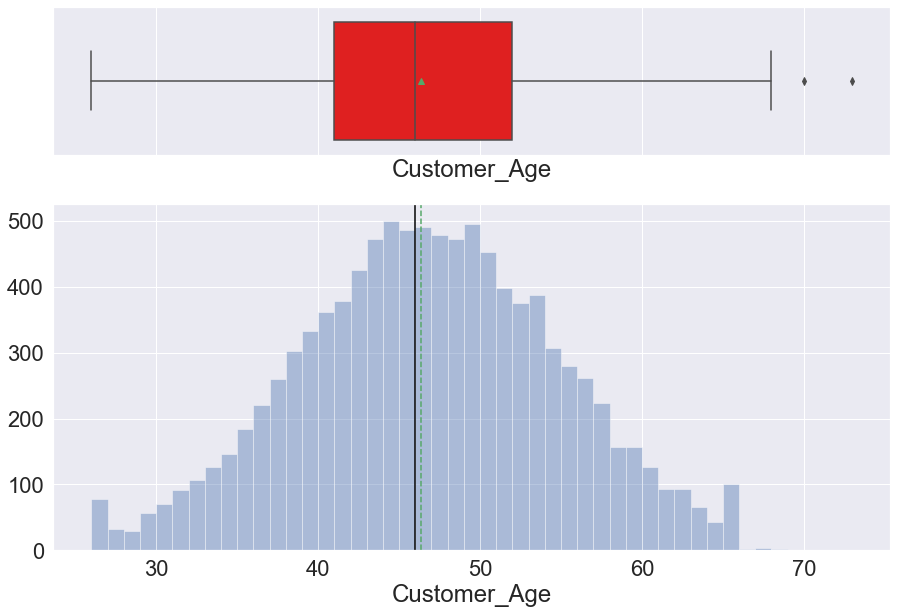

In [17]:
histogram_boxplot(bank["Customer_Age"])

- Customers age range from 26 to 73.
- Age distribution is almost normal with a mean of 46 years.
- Two observations' `Age` are flagged by the boxplot as outliers.

### Observation of `Months_on_book`

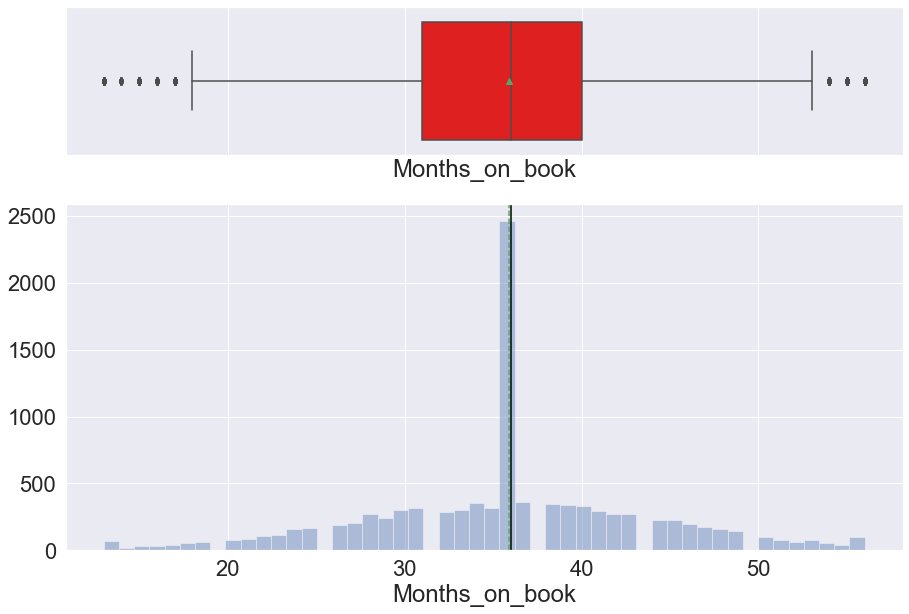

In [18]:
histogram_boxplot(bank["Months_on_book"])

- Time spent by customers with bank range form few months up to around 5 years.
- Mean time spent is about 36 months.

### Observation of `Credit_Limit`

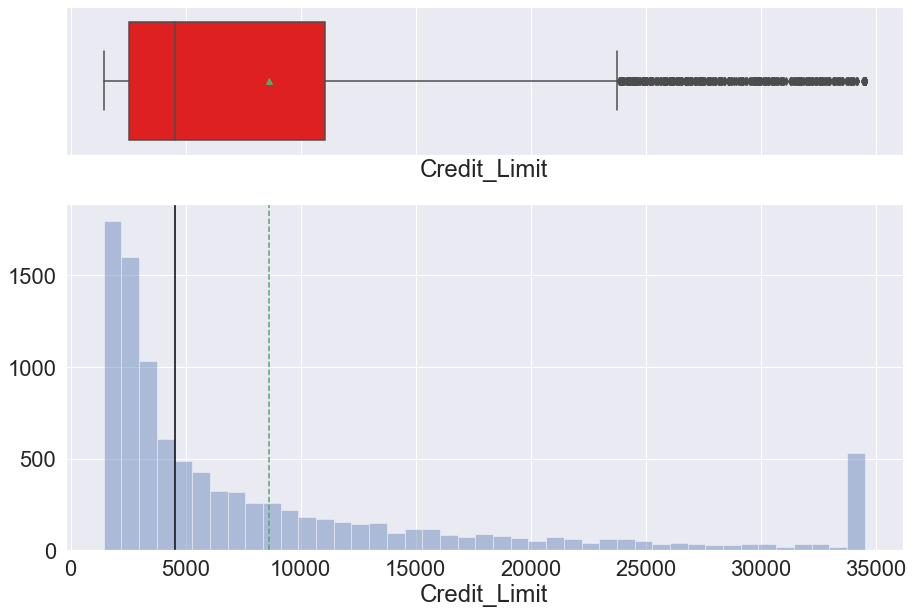

In [19]:
histogram_boxplot(bank["Credit_Limit"])

- Credit limit ranges from few 1500 to 35000.
- However, half of the customers have a limit of 5000, so the distribution is largely inequal with many flagged as outliers.

### Observation of `Total_Revolving_Bal`

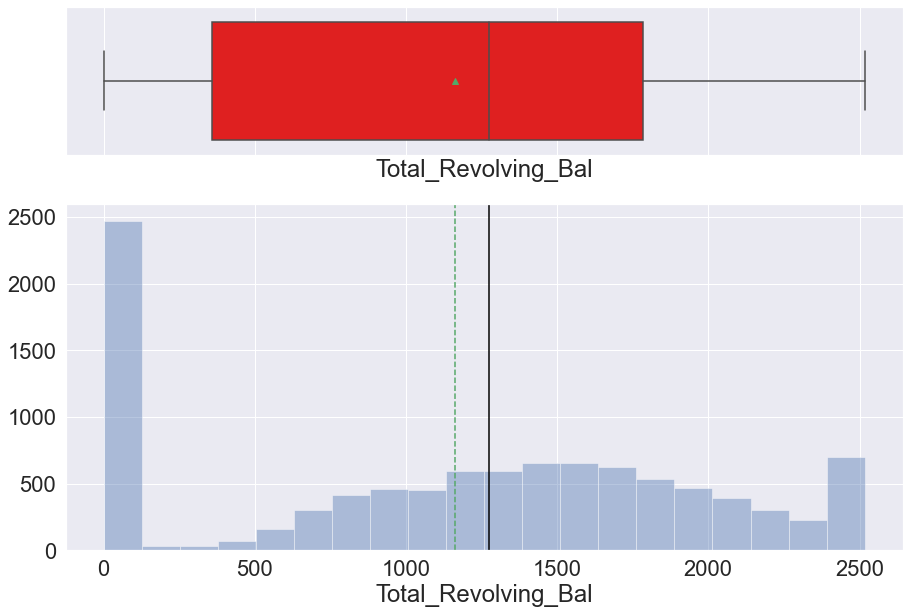

In [20]:
histogram_boxplot(bank["Total_Revolving_Bal"])

- Many customers have a revolving balance of zero, meaning they paid (if they did use) their balance in full.
- Left aside the above mentioned special case, average total revolving is about 1150 and a median of 1250.

### Observation of `Avg_Open_To_Buy`

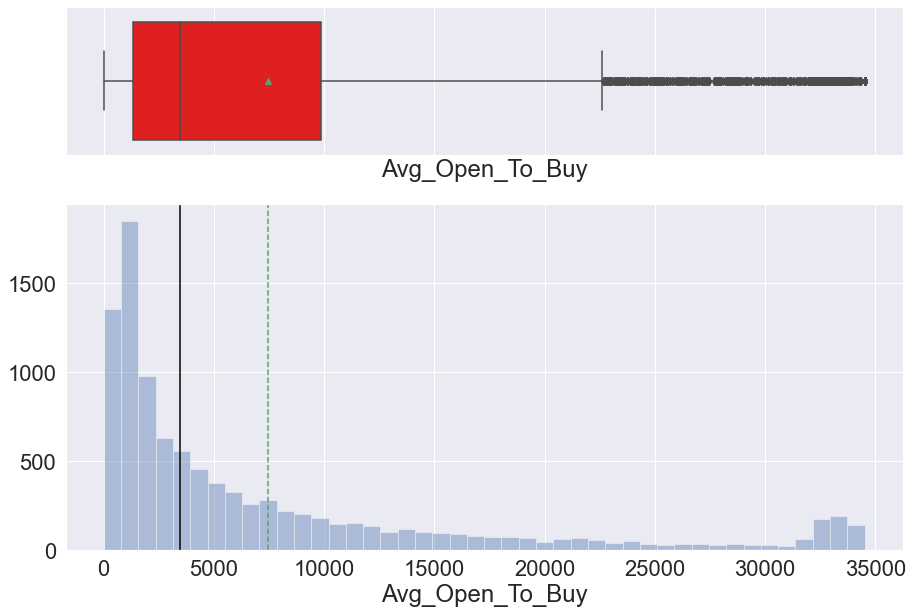

In [21]:
histogram_boxplot(bank["Avg_Open_To_Buy"])

- `Avg_Open_To_Buy` is higly right skewed, which was expectable since it follows the distribution of `Credit_Limit`.

### Observation of `Total_Amt_Chng_Q4_Q1`

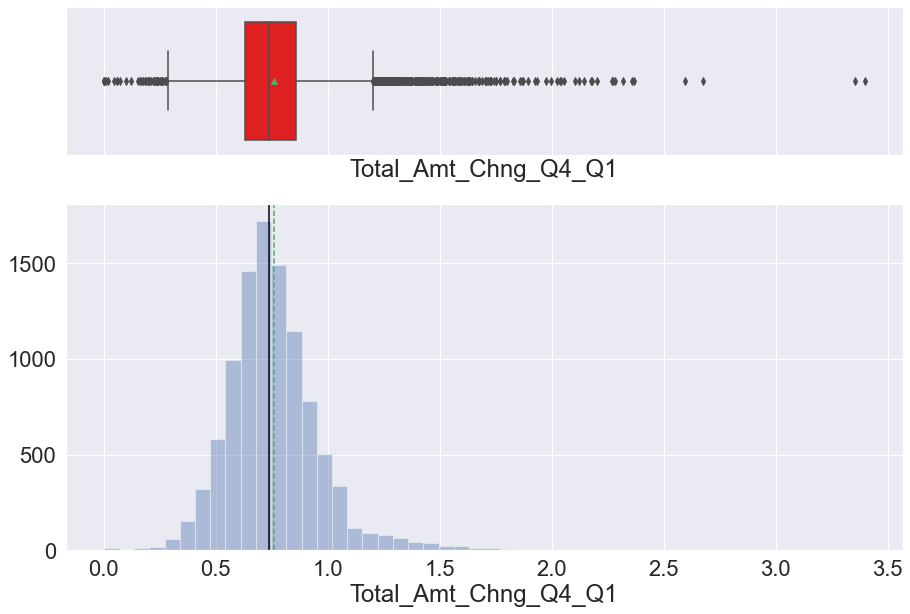

In [22]:
histogram_boxplot(bank["Total_Amt_Chng_Q4_Q1"])

- `Total_Amt_chng_Q4_Q1` has a quasi-normal distribution, with a mean of about 0.75 and a third percentile of aboutt 0.83, meaning most of the customers spent more money on their credit card in the first quarter of the year than in the fourth.
- However, there is a lot of observations flagged as outliers.

### Observation of `Total_Trans_Amt`

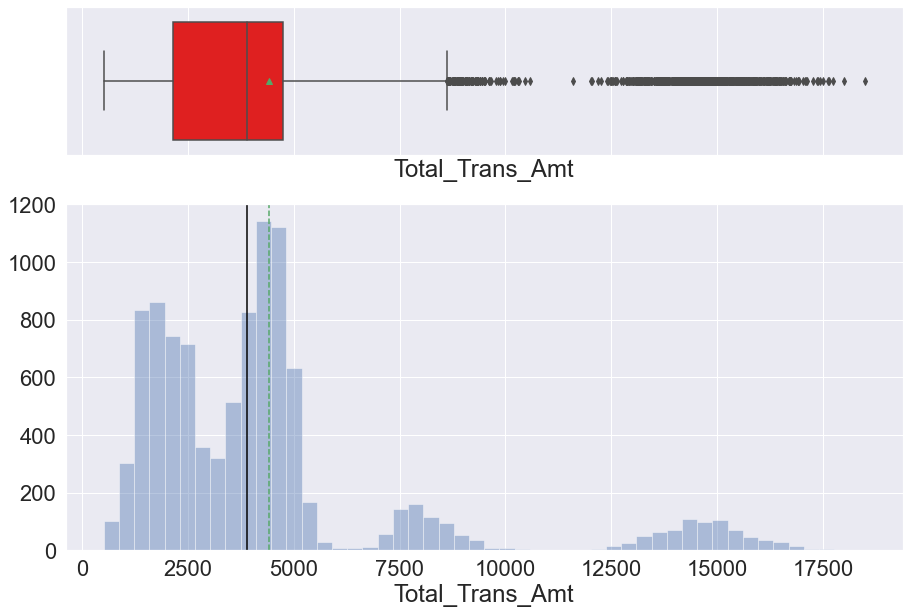

In [23]:
histogram_boxplot(bank["Total_Trans_Amt"])

- `Total_Trasn_Amt` distribution is right skewed.
- Median Total Transaction Amount is about 4000.
- Plots seem to show two groups, whence the high number of outliers to the right.

### Observation of `Total_Ct_Chng_Q4_Q1`

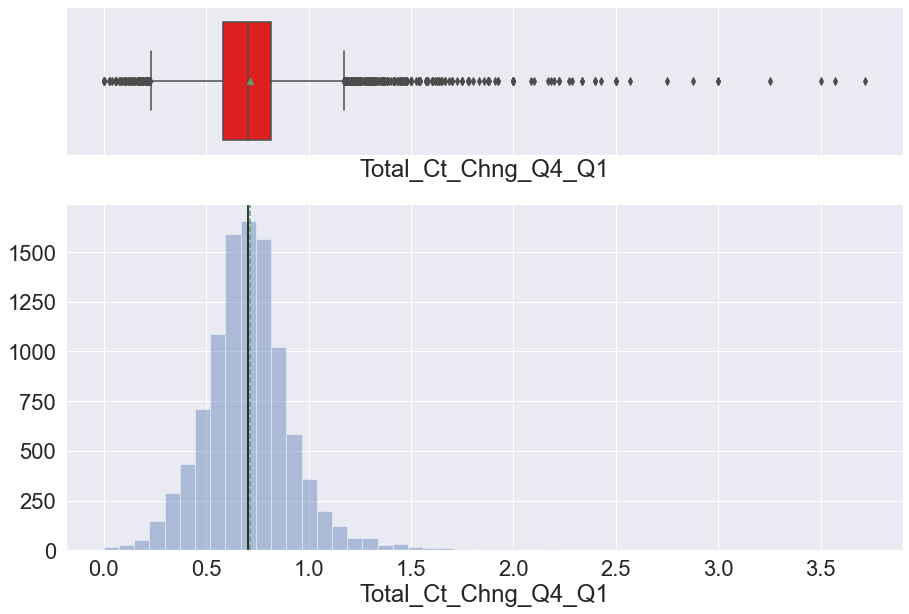

In [24]:
histogram_boxplot(bank["Total_Ct_Chng_Q4_Q1"])

- `Total_Ct_Chng_Q4_Q1` has a quasi-normal distribution.
- The mean is about 0.75
- The higher amount spent in the first quarter of the year as compared to the fourth may follow a higher number of transaction.
- However, we register a lot of observations flagged as outliers.

### Observation of `Avg_Utilization_Ratio`

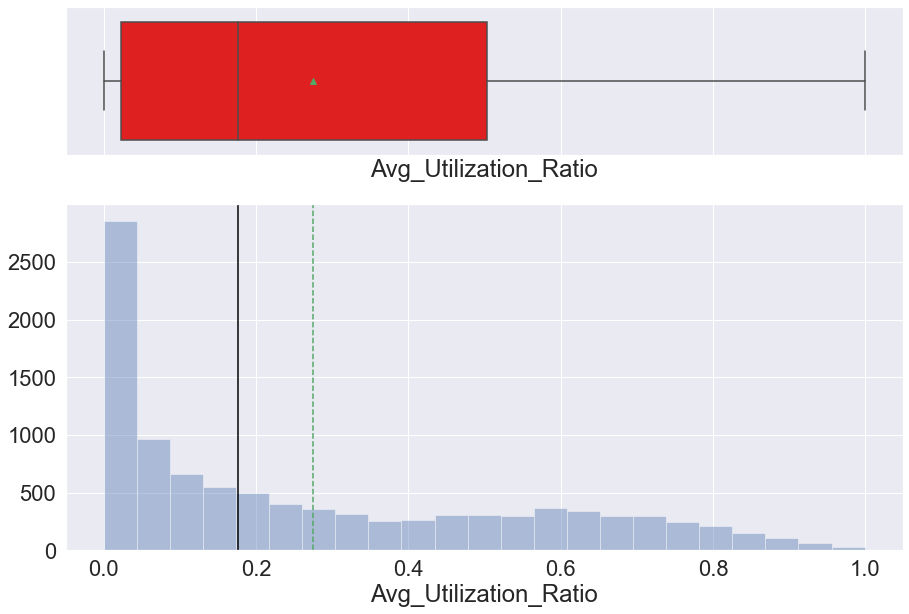

In [25]:
histogram_boxplot(bank["Avg_Utilization_Ratio"])

- The credit card utilization ratio is very low.
- Half of customers did use less than 20% of their line of credit. Mean credit usage is about 30%.
With more than 1/4 of customers having a zero percent averge usage, there are some high consuming customers.

### Observation of `Total_Trans_Ct`

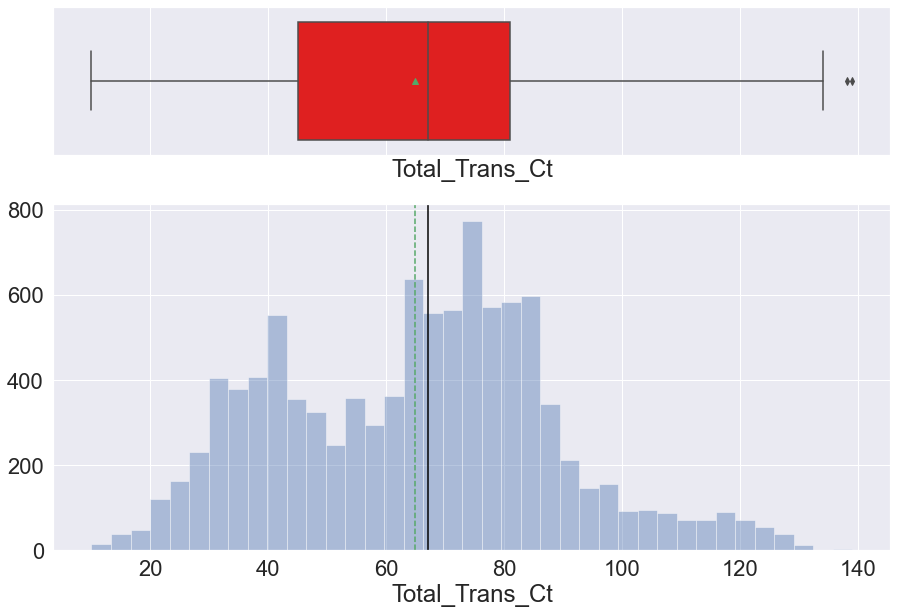

In [26]:
histogram_boxplot(bank["Total_Trans_Ct"])

- Customers made an average of about 65 transactions. Median number of transaction is about 67.

In [27]:
## Function to plot non-continuous and categorical variables.


def bar_plot(var, hue=None, figsize=(8, 7), ax=None):

    plt.figure(figsize=figsize)
    plots = sns.countplot(var, hue=hue)
    for item in plots.patches:
        percent = f"{item.get_height()} ({item.get_height()/len(var):.1%})"
        x = item.get_x() + item.get_width() / 2
        y = item.get_height()
        plots.annotate(
            percent,
            (x, y),
            size=12,
            xytext=(0, 8),
            va="center",
            ha="center",
            textcoords="offset points",
        )
    plt.show()

### Observation of `Dependent_count`

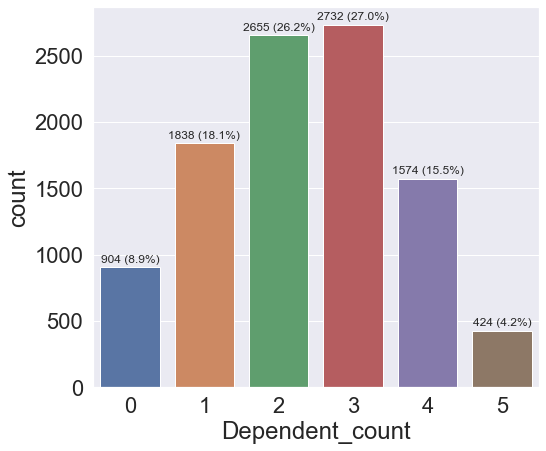

In [28]:
bar_plot(bank["Dependent_count"])

Most customers have at least one dependent. However, the large majority have 2 or 3 dependents.

### Observation of `Total_Relationship_Count`

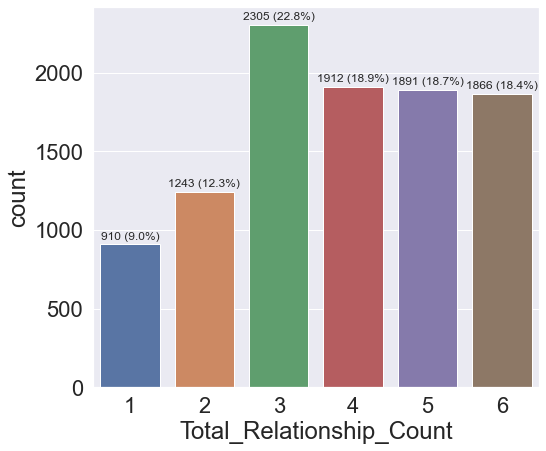

In [29]:
bar_plot(bank["Total_Relationship_Count"])

Customers typically hold at least 3 products with the bank.

### Observation of `Months_Inactive_12_mon`

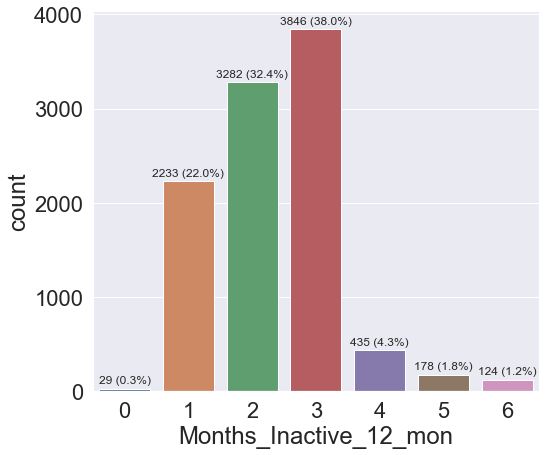

In [30]:
bar_plot(bank["Months_Inactive_12_mon"])

Customers typically spent from 1 to 3 months of inactivity in the last 12 month period. 

### Observation of `Contacts_Count_12_mon`

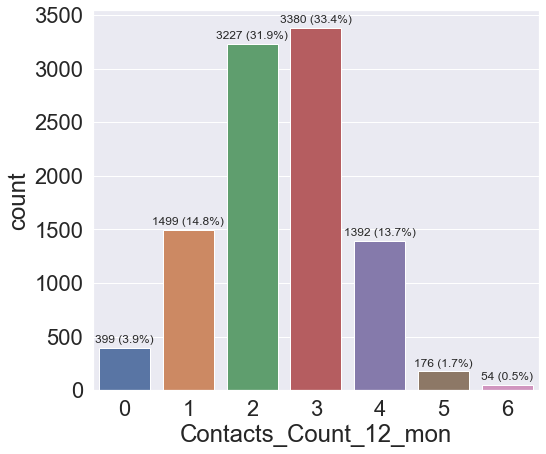

In [31]:
bar_plot(bank["Contacts_Count_12_mon"])

The large majority of customers had 2 or 3 contacts with the bank in the last 12 month period.

### Observation of `Gender`

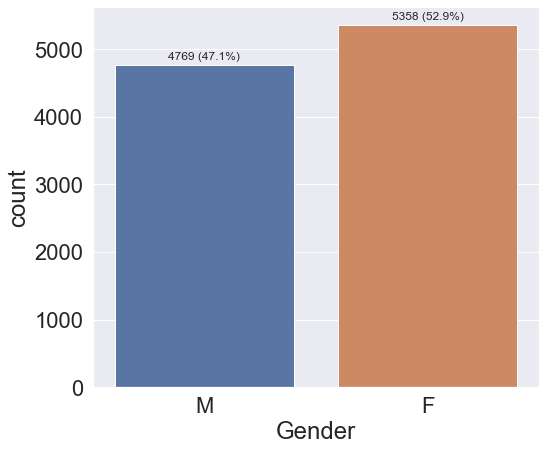

In [32]:
bar_plot(bank["Gender"])

Women are more represented in the dataset than men.

### Observation of `Education_Level`

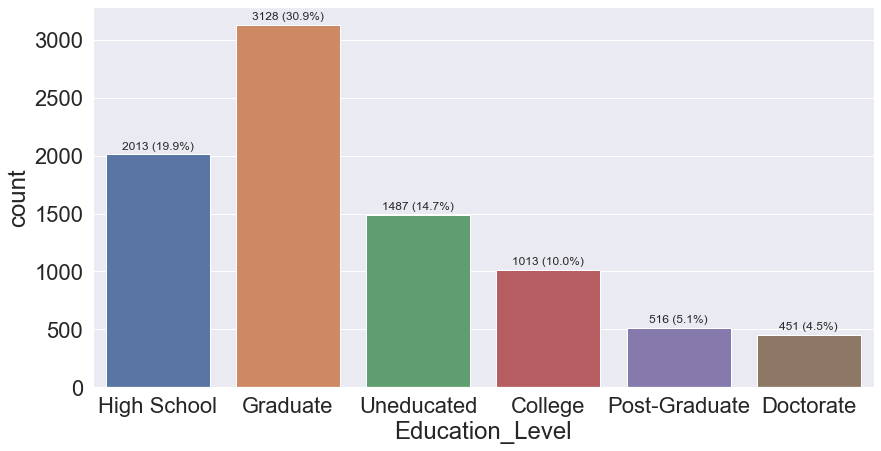

In [33]:
bar_plot(bank["Education_Level"], figsize=(14, 7))

About 15% of customers are uneducated. Among the educated customers, graduate are the most represented.

### Observation of `Marital_Status`

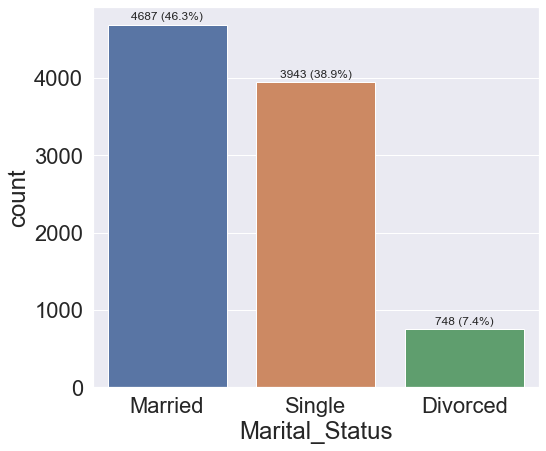

In [34]:
bar_plot(bank["Marital_Status"])

Most customers are married, and a significant number are single. Very few were divorced.

### Observation of `Income_Category`

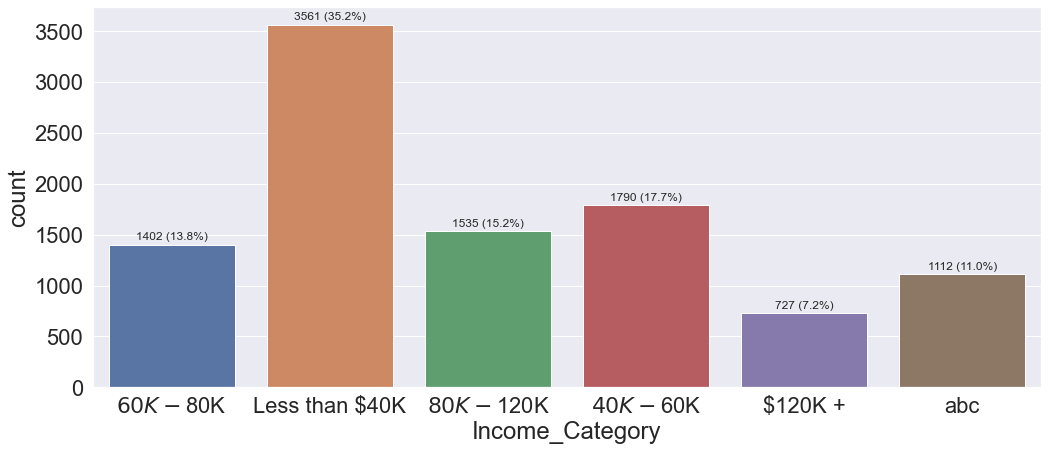

In [35]:
bar_plot(bank["Income_Category"], figsize=(17, 7))

- Income is skewed to the right.
- More than one-third of customers earn less than 40K; about 47% of them earn between 40K and 120K, and 7% above 120K.
- We notice that income of an important fraction of customers (11%) have not been classified.

### Observation of `Card_Category`

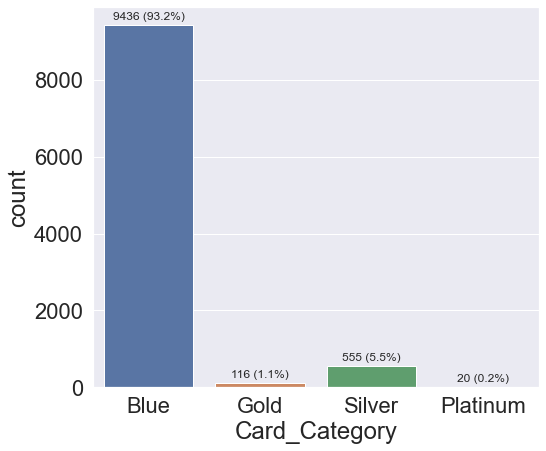

In [36]:
bar_plot(bank["Card_Category"])

- Blue card is by far the most used card by customers.
- Very few customers use other card categories, but still, we can observe that the higher the card category, the less the number of customers that use it.

### Observation of `Attrition_Flag`

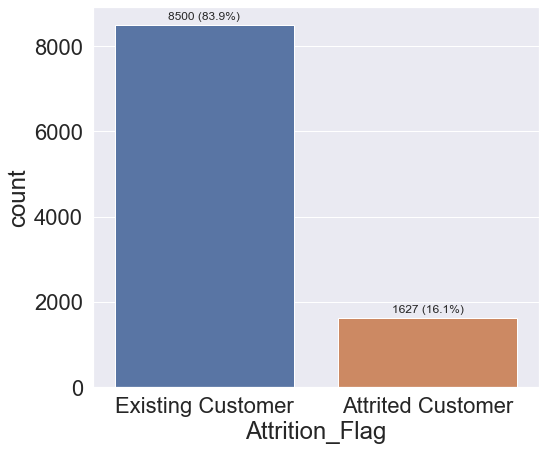

In [37]:
bar_plot(bank["Attrition_Flag"])

Large majority of customers are existing customers. Only 16% have attrited, making highly imbalanced data.

# <a name = 'link22'>2.2. Bivariate Analysis</a>

### Pairplot to visualize relations

<Figure size 1080x720 with 0 Axes>

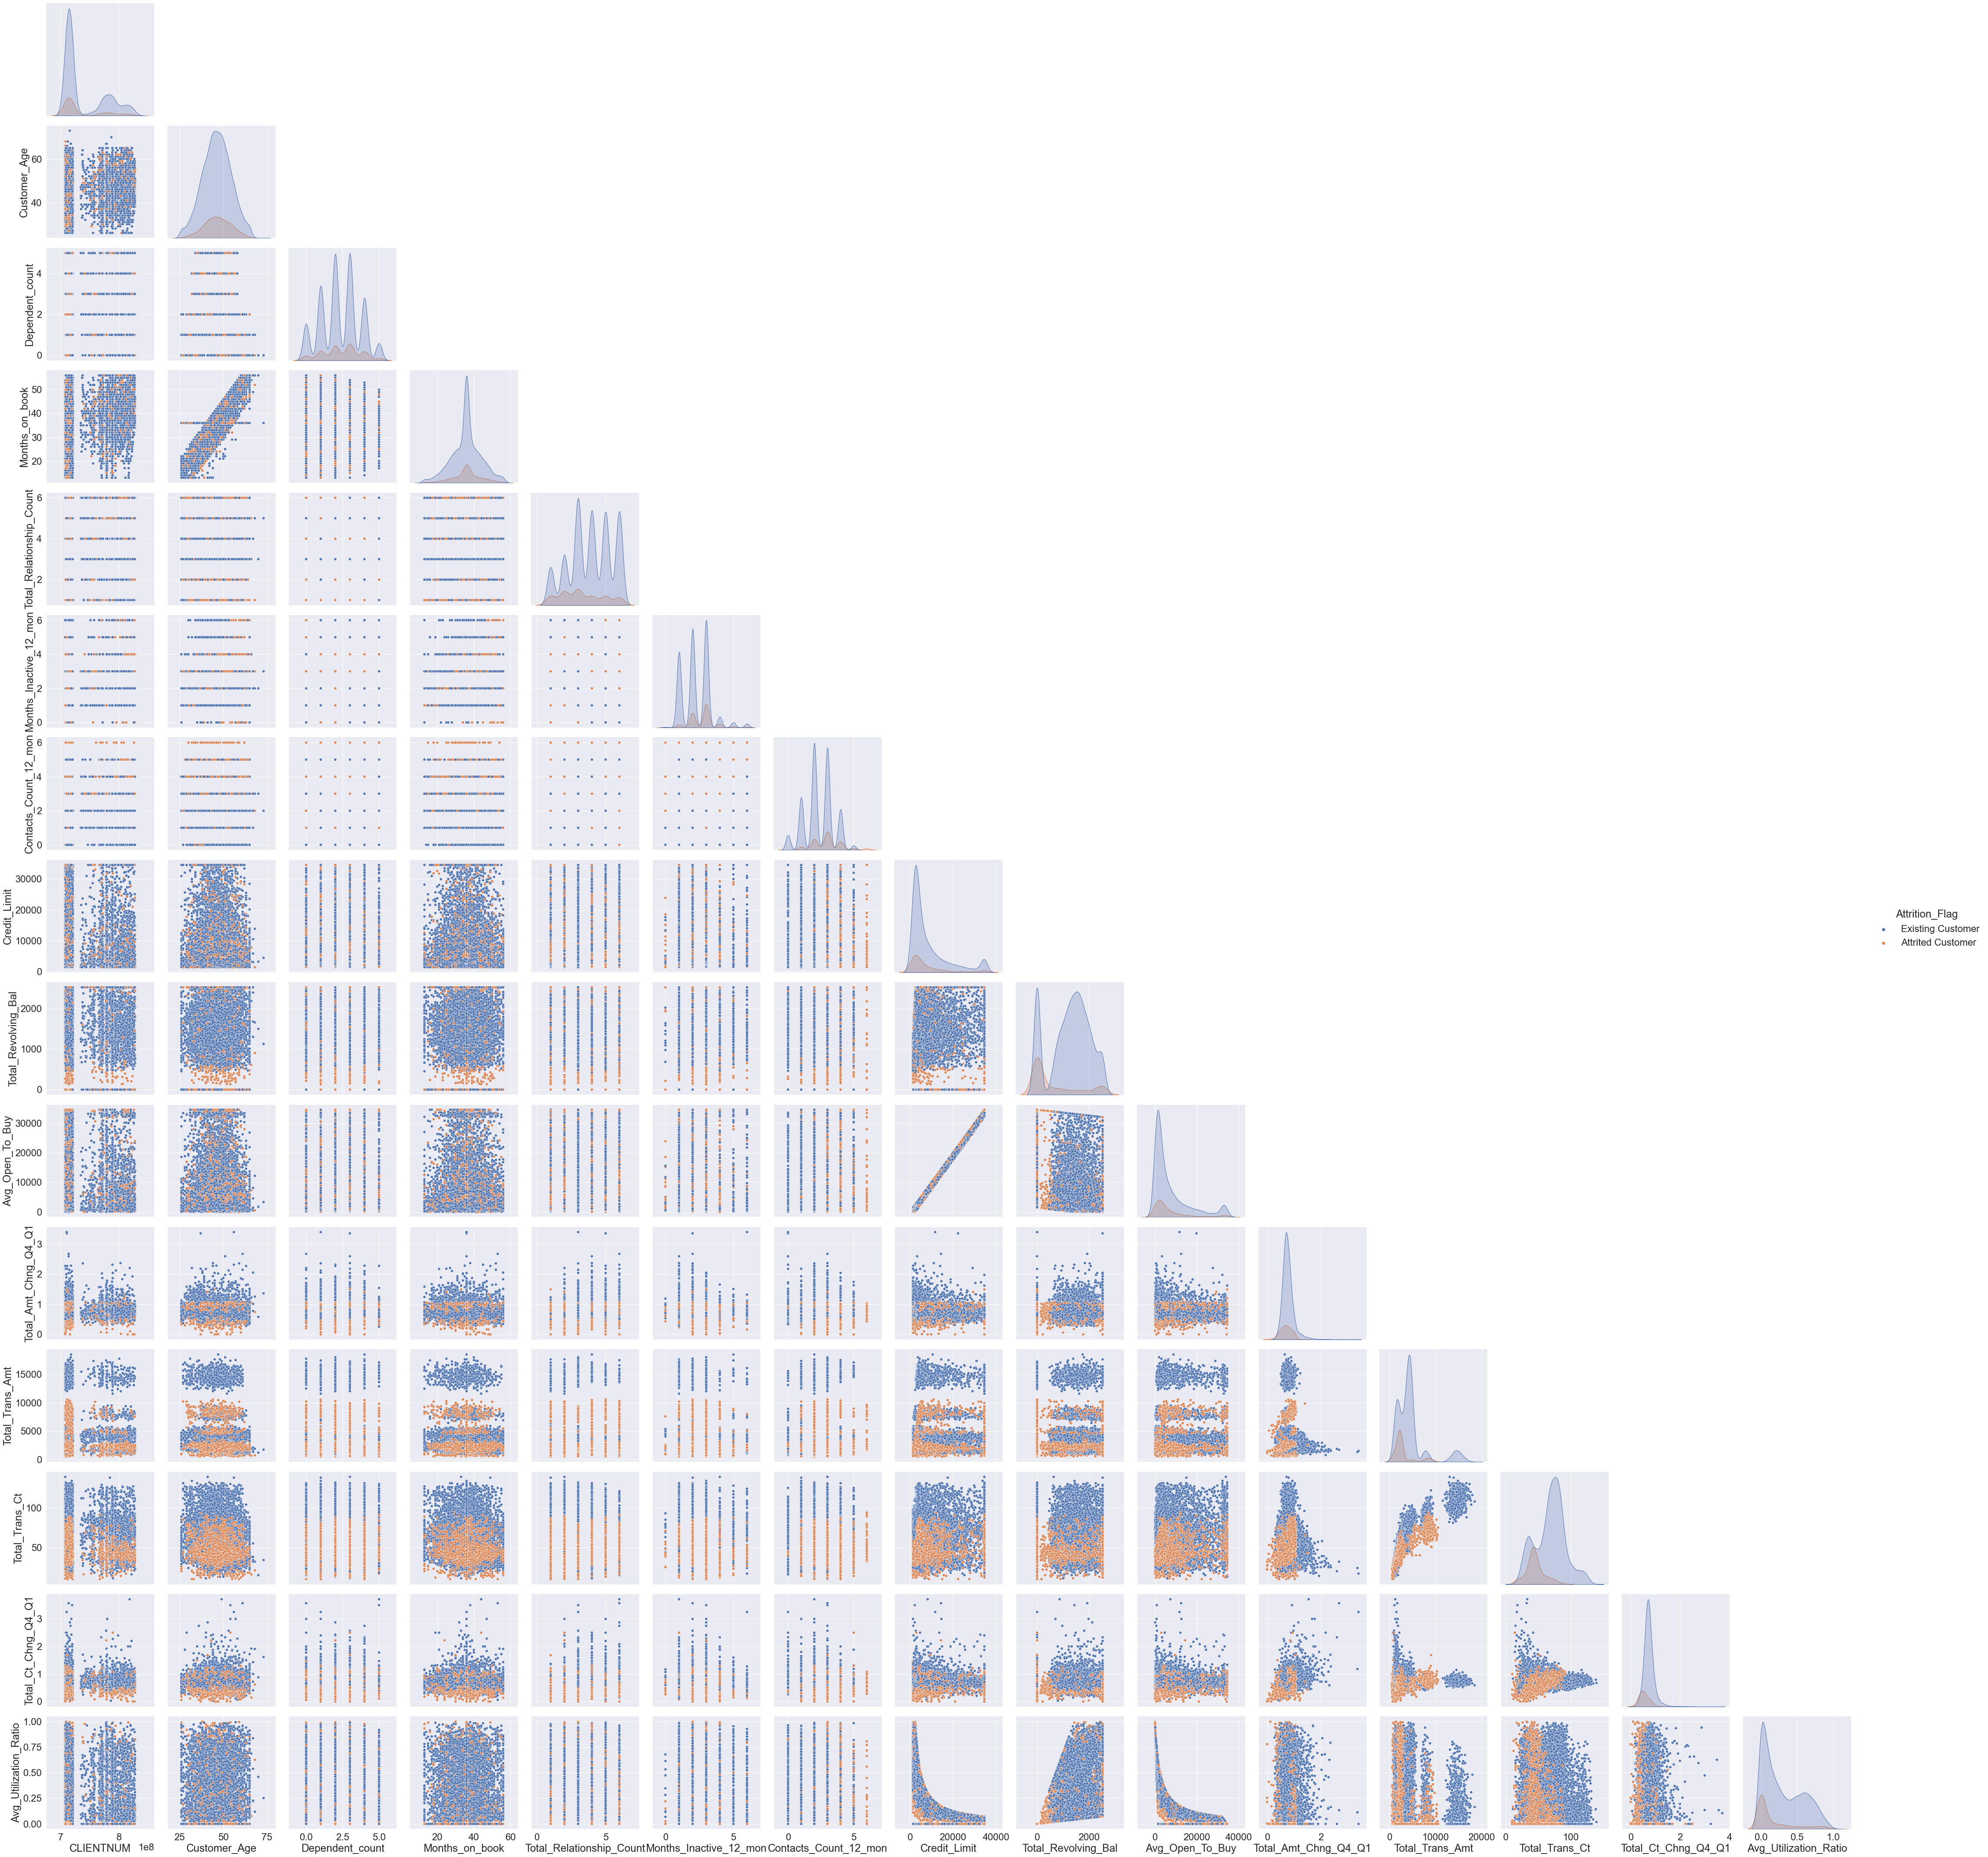

In [38]:
plt.figure(figsize=(15, 10))
sns.pairplot(bank, hue="Attrition_Flag", diag_kind="kde", corner=True, size=4)
plt.show()

- `Customer_Age` and `Month_on_book` are  highly positively correlated, which is intuitive.
-  Also `Credit_Limit` and `Avg_Open_To_Buy` are perfectly correlated. This as well is intuitive because the more credit you have, the less likely you are to consume all, and thus the more you have left to use.
- `Total_Trans_Amt` and `Total_Trans_Ct` are positively correlated. Here also, it is intuitive for the more transaction you make, the more you spend.

### Heatmap to see correlations

<AxesSubplot:>

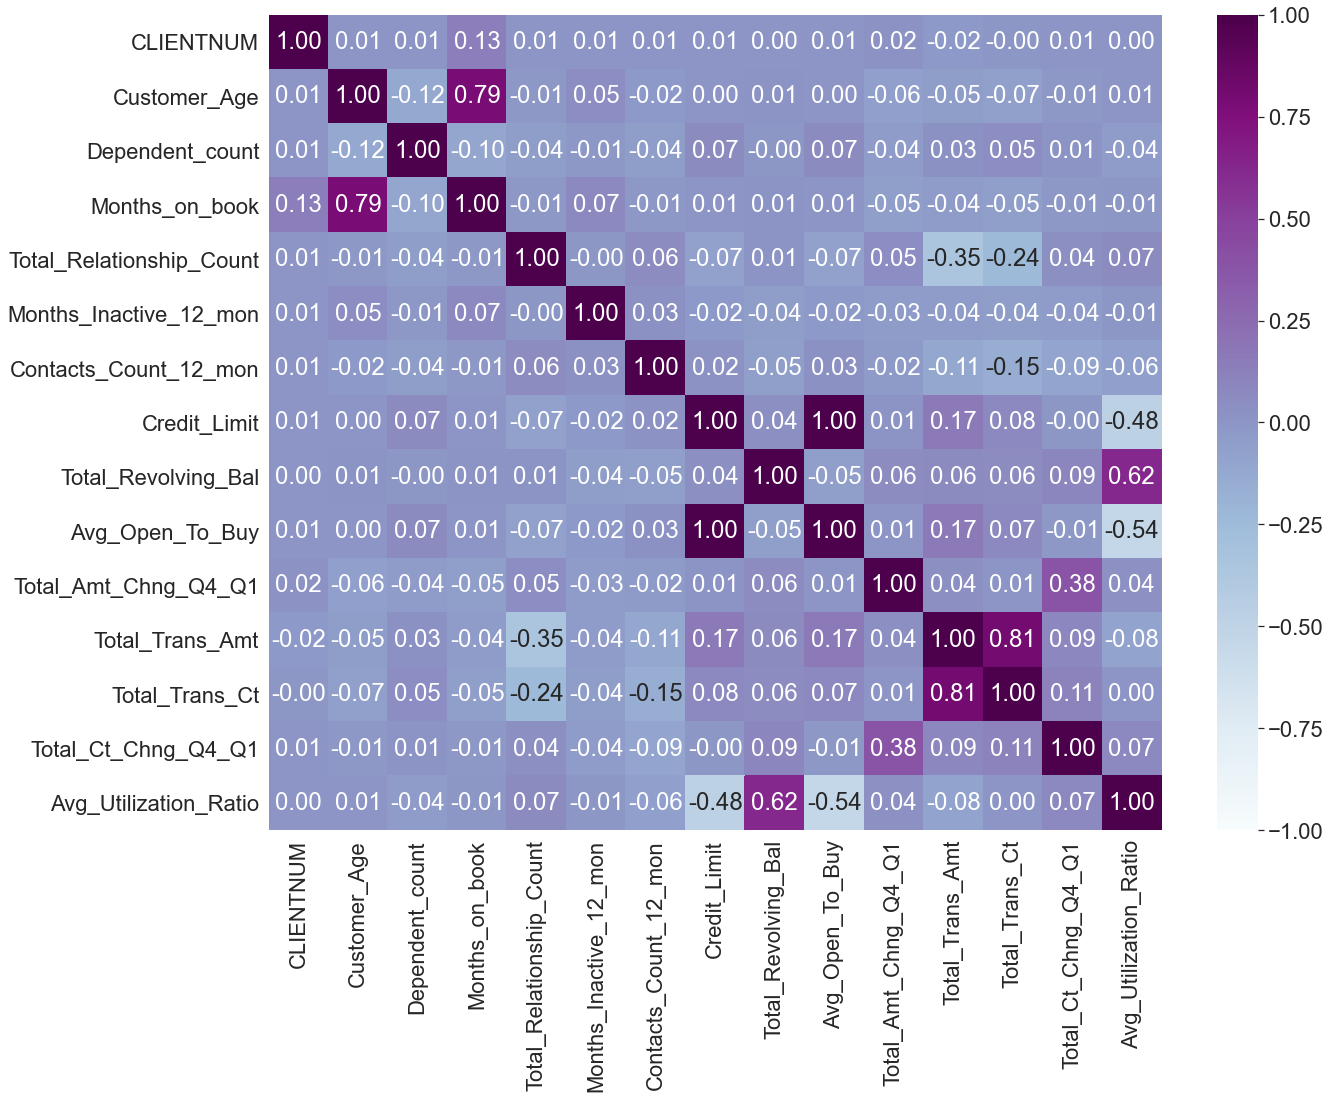

In [39]:
plt.figure(figsize=(20, 15))
sns.heatmap(bank.corr(), cmap="BuPu", annot=True, vmin=-1, vmax=1, fmt=".2f")

Apart from the above mentioned relashionship between variables, we can note the following as well:
- There is a negative correlation between `Avg_Utilization_Ratio` and `Avg_Open_To_Buy`. In fact, having more credit left to use means one has used less of the credit available.
- There also is a negative correlation between `Avg_Utilization_Ratio` and `Credit_limit` meaning people with higher credit line  have a lower utilization.

### `Atrition_Flag` vs `Customer_Age`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Customer_Age'>

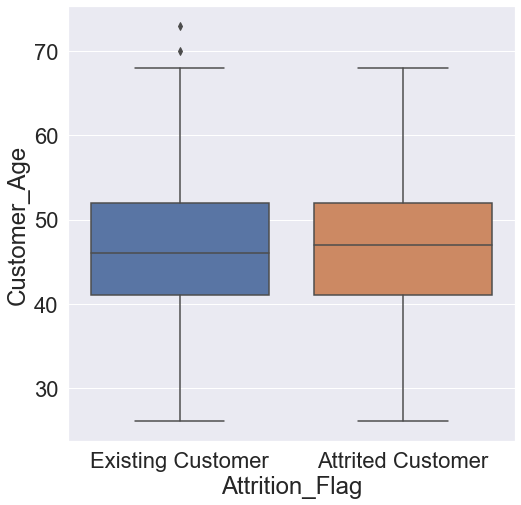

In [40]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Customer_Age")

Attrited and Existing customers have the same distribustion of Age. However, Attrited customers' median Age is slightly higher than Existing Customers'.

### `Attrition_Flag` vs `Months_on_book`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Months_on_book'>

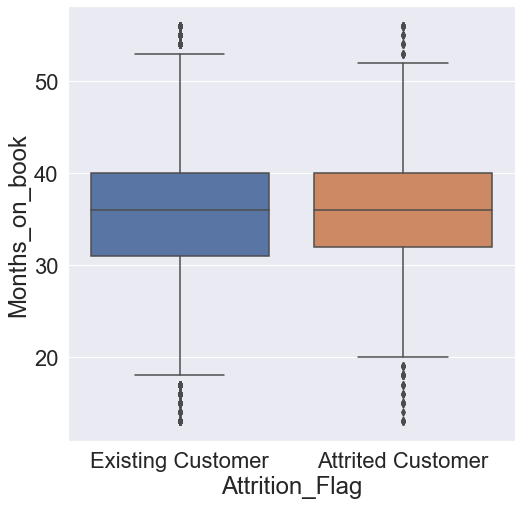

In [41]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Months_on_book")

Attrition is not dependent on the length of time a customer spent with the bank, that is new customers as well as old ones attrited.

### `Attrition_Flag` vs `Credit_Limit`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Credit_Limit'>

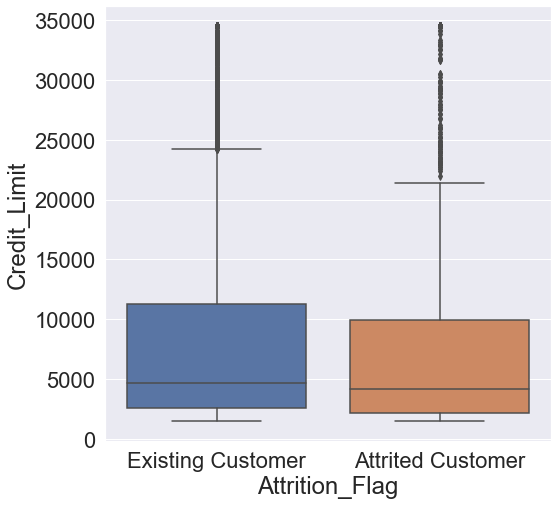

In [42]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Credit_Limit")

Attrited customers typically have slightly lower credit limit than Existing customers.

### `Attrition_Flag` vs `Total_Revolving_Bal`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Total_Revolving_Bal'>

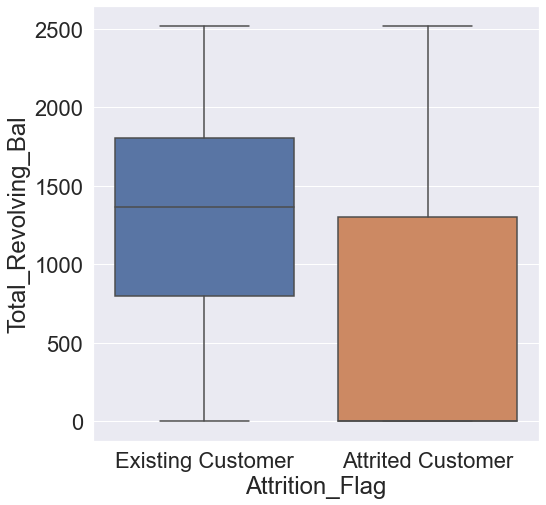

In [43]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Total_Revolving_Bal")

Attrited customers have lower total revolving balance than Existing customers.

### `Attrition_Flag` vs `Avg_Open_To_Buy`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Avg_Open_To_Buy'>

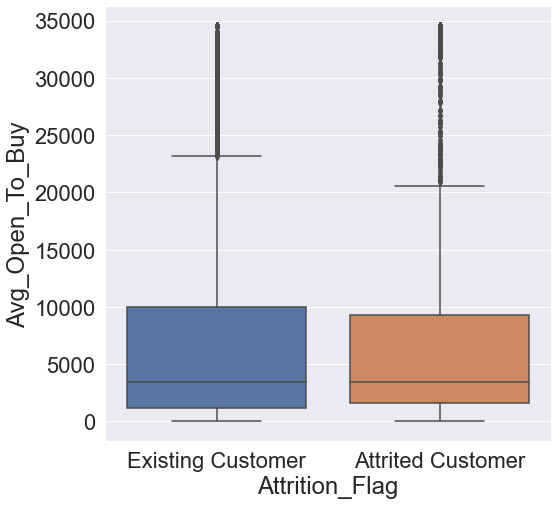

In [44]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Avg_Open_To_Buy")

Typically attrited customers have slightly less remaining credit than existing customers.

### `Attrition_Flag` vs `Total_Amt_Chng_Q4_Q1`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Total_Amt_Chng_Q4_Q1'>

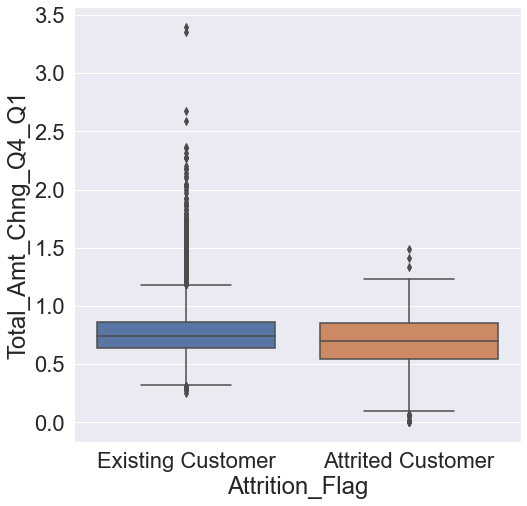

In [45]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Total_Amt_Chng_Q4_Q1")

Ratio of the total transaction amount in 4th quarter and the total transaction amount in 1st quarter for attrited customers is lower than that of existing ones.

### `Attrition_Flag` vs `Total_Ct_Chng_Q4_Q1`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Total_Ct_Chng_Q4_Q1'>

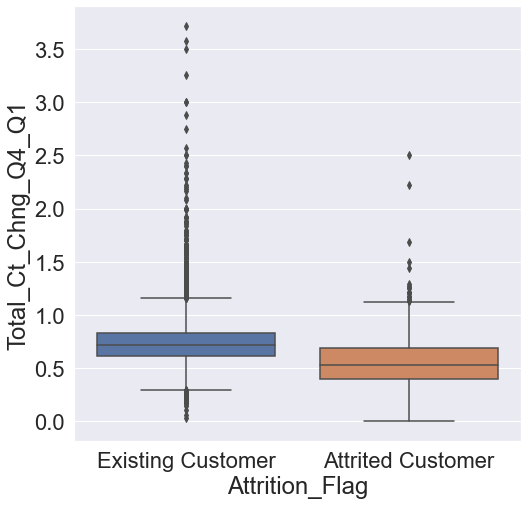

In [46]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Total_Ct_Chng_Q4_Q1")

Ratio of the total transaction count in 4th quarter and the total transaction count in 1st quarter for attribited customers in lower than that of existing ones.

### `Attrition_Flag` vs `Total_Trans_Amt`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Total_Trans_Amt'>

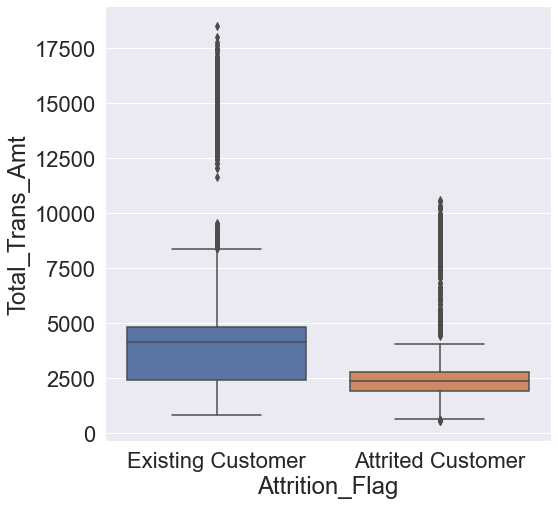

In [47]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Total_Trans_Amt")

Total transaction amount for existing customers is typically greater thant that of attrited ones.

### `Attrition_Flag` vs `Total_Trans_Ct`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Total_Trans_Ct'>

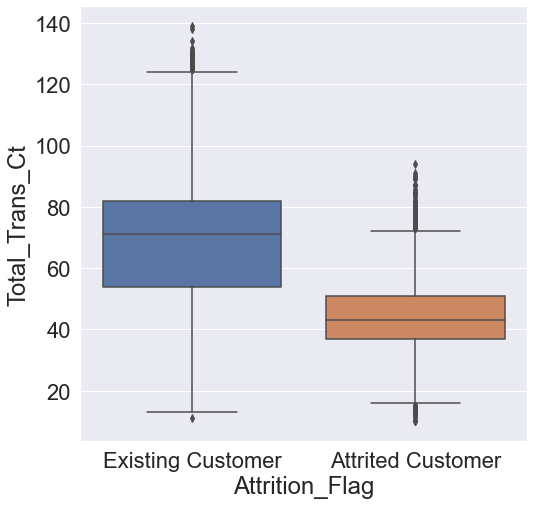

In [48]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Total_Trans_Ct")

Attrited customers typically made about 45 transactions, by far less than the 70 existing customers made.

### `Attrition_Flag` vs `Avg_Utilization_Ratio`

<AxesSubplot:xlabel='Attrition_Flag', ylabel='Avg_Utilization_Ratio'>

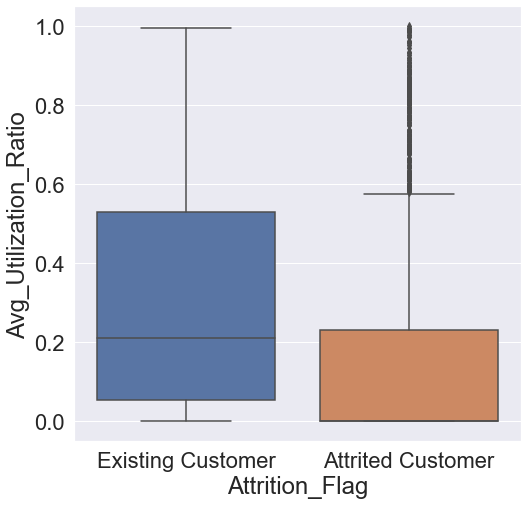

In [49]:
plt.figure(figsize=(8, 8))
sns.boxplot(data=bank, x="Attrition_Flag", y="Avg_Utilization_Ratio")

Attrited customers typically consume less of their credit line than existing ones.

In [50]:
# A function to plot stacked bar charts for non-continuous and categorical columns


def stacked_plot(x):
    sns.set(palette="tab10")
    tab1 = pd.crosstab(x, bank["Attrition_Flag"], margins=True)
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(x, bank["Attrition_Flag"], normalize="index")
    tab.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.legend(loc="lower left", frameon=False)
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

### `Attrition_Flag` vs `Dependent_count`

Attrition_Flag   Attrited Customer  Existing Customer    All
Dependent_count                                             
0                              135                769    904
1                              269               1569   1838
2                              417               2238   2655
3                              482               2250   2732
4                              260               1314   1574
5                               64                360    424
All                           1627               8500  10127
------------------------------------------------------------------------------------------------------------------------


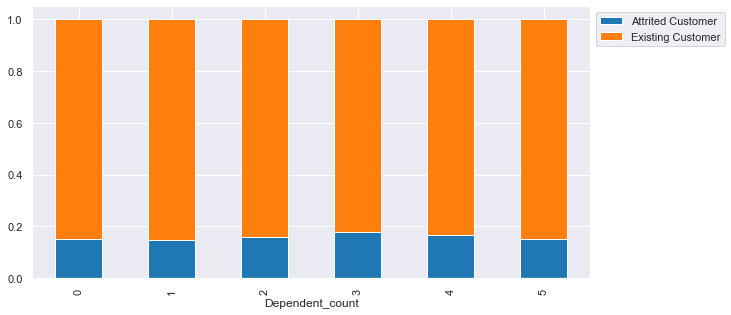

In [51]:
stacked_plot(bank["Dependent_count"])

Attrition is not related to number of descendents.

### `Attrition_Flag` vs `Gender`

Attrition_Flag  Attrited Customer  Existing Customer    All
Gender                                                     
F                             930               4428   5358
M                             697               4072   4769
All                          1627               8500  10127
------------------------------------------------------------------------------------------------------------------------


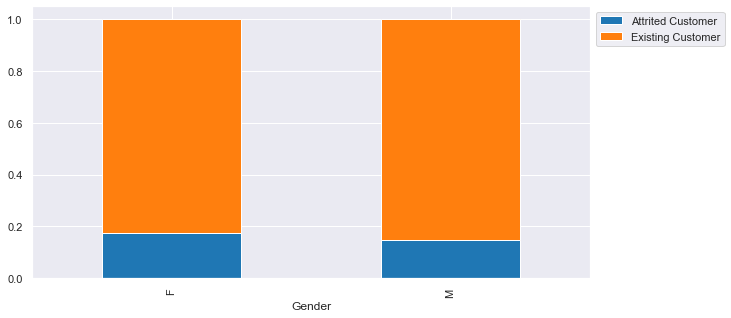

In [52]:
stacked_plot(bank["Gender"])

A slightly greater proportion of female customers attrited, as compare to male.

### `Attrition_Flag` vs `Education_Level`

Attrition_Flag   Attrited Customer  Existing Customer   All
Education_Level                                            
College                        154                859  1013
Doctorate                       95                356   451
Graduate                       487               2641  3128
High School                    306               1707  2013
Post-Graduate                   92                424   516
Uneducated                     237               1250  1487
All                           1371               7237  8608
------------------------------------------------------------------------------------------------------------------------


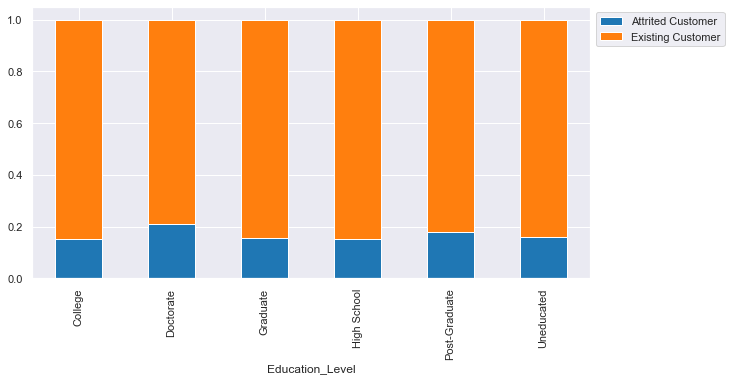

In [53]:
stacked_plot(bank["Education_Level"])

Attrited customers are almost uniformly distributed among different level of education. Still the higher educated attrited the most.

### `Attrition_Flag` vs `Marital_Status`

Attrition_Flag  Attrited Customer  Existing Customer   All
Marital_Status                                            
Divorced                      121                627   748
Married                       709               3978  4687
Single                        668               3275  3943
All                          1498               7880  9378
------------------------------------------------------------------------------------------------------------------------


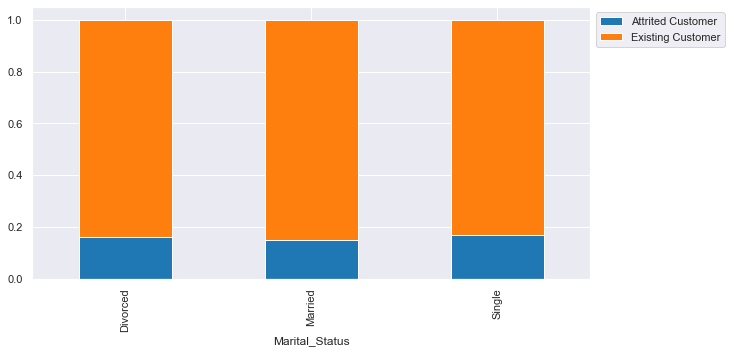

In [54]:
stacked_plot(bank["Marital_Status"])

Customer attrition is not highly related to marital status. However, we can notice that married customers attrited the less. Single customers have the higher proportion of attrition.

### `Attrition_Flag` vs `Income_Category`

Attrition_Flag   Attrited Customer  Existing Customer    All
Income_Category                                             
$120K +                        126                601    727
$40K - $60K                    271               1519   1790
$60K - $80K                    189               1213   1402
$80K - $120K                   242               1293   1535
Less than $40K                 612               2949   3561
abc                            187                925   1112
All                           1627               8500  10127
------------------------------------------------------------------------------------------------------------------------


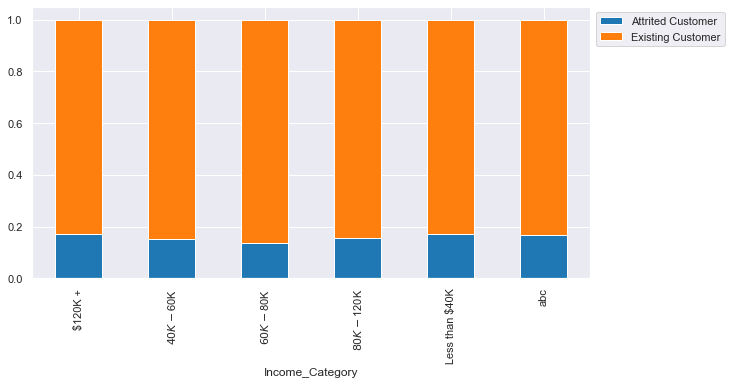

In [55]:
stacked_plot(bank["Income_Category"])

Customers of all level of income did attrite, though can notice a higher level in the lower income category.

### `Attrition_Flag` vs `Card_Category`

Attrition_Flag  Attrited Customer  Existing Customer    All
Card_Category                                              
Blue                         1519               7917   9436
Gold                           21                 95    116
Platinum                        5                 15     20
Silver                         82                473    555
All                          1627               8500  10127
------------------------------------------------------------------------------------------------------------------------


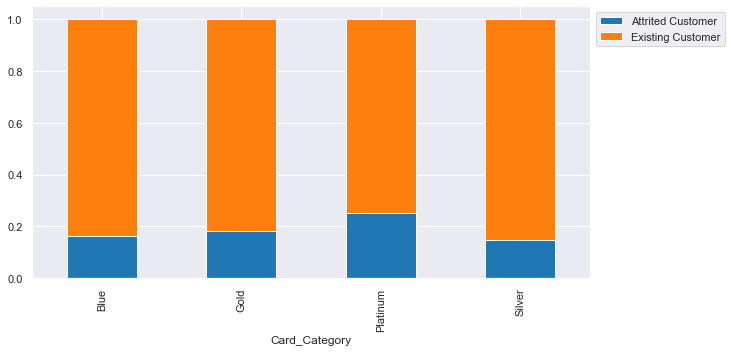

In [56]:
stacked_plot(bank["Card_Category"])

Slightly more Platinum card holder did attrite compared to customers holding other card categories. Silver card holders attrited the less.

### `Attrition_Flag` vs `Total_Relationship_Count`

Attrition_Flag            Attrited Customer  Existing Customer    All
Total_Relationship_Count                                             
1                                       233                677    910
2                                       346                897   1243
3                                       400               1905   2305
4                                       225               1687   1912
5                                       227               1664   1891
6                                       196               1670   1866
All                                    1627               8500  10127
------------------------------------------------------------------------------------------------------------------------


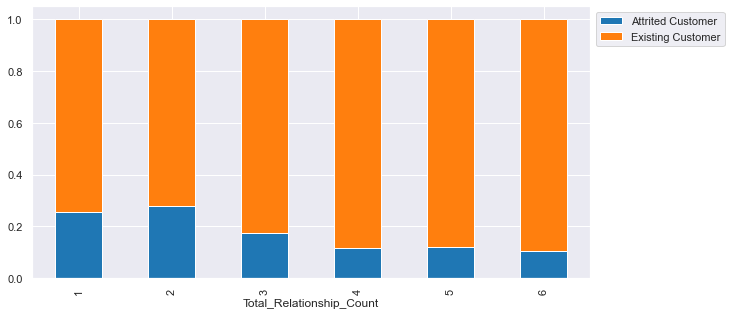

In [57]:
stacked_plot(bank["Total_Relationship_Count"])

The more the number of products customers hold, the less they attrite.

### `Attrition_Flag` vs `Months_Inactive_12_mon`

Attrition_Flag          Attrited Customer  Existing Customer    All
Months_Inactive_12_mon                                             
0                                      15                 14     29
1                                     100               2133   2233
2                                     505               2777   3282
3                                     826               3020   3846
4                                     130                305    435
5                                      32                146    178
6                                      19                105    124
All                                  1627               8500  10127
------------------------------------------------------------------------------------------------------------------------


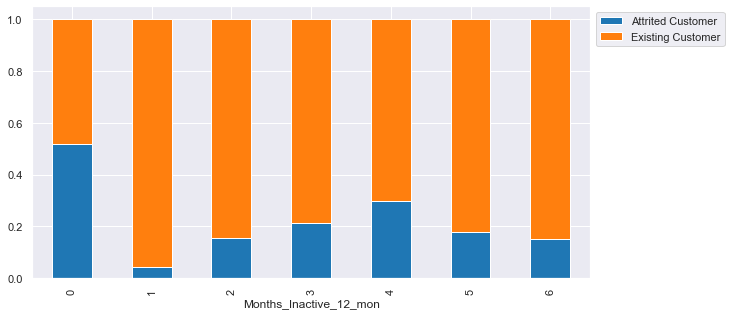

In [58]:
stacked_plot(bank["Months_Inactive_12_mon"])

- The most attrited customers were active through out the last 12 months.
- Customers with only one month of inactivity in the last twelve months attrited the less.

### `Attrition_Flag` vs `Contacts_Count_12_mon`

Attrition_Flag         Attrited Customer  Existing Customer    All
Contacts_Count_12_mon                                             
0                                      7                392    399
1                                    108               1391   1499
2                                    403               2824   3227
3                                    681               2699   3380
4                                    315               1077   1392
5                                     59                117    176
6                                     54                  0     54
All                                 1627               8500  10127
------------------------------------------------------------------------------------------------------------------------


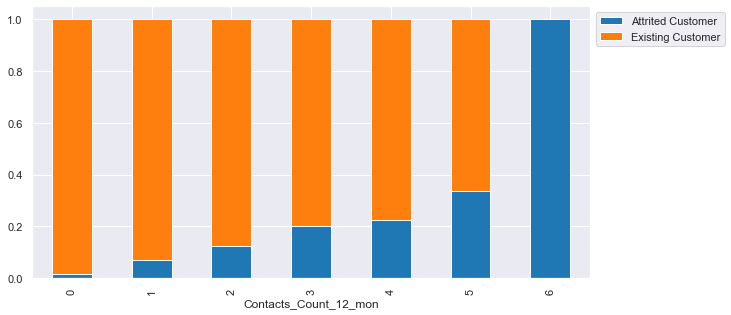

In [59]:
stacked_plot(bank["Contacts_Count_12_mon"])

Attrition increases with the number of contacts with the bank in the last twelve months.

# <a name = 'link3'> 3. Data preprocesing</a>

## <a name = 'link31'> 3.1. Data preparation</a>

### Dropping the `CLIENTNUM` column

The `CLIENTNUM` column hold no relevent information for our analysis, so we just drop it.

In [60]:
bank.drop(columns=["CLIENTNUM"], inplace=True)

### Converting `object` type columns to `category`

In [61]:
cat_col = list(bank.select_dtypes(include=["object"]).columns)
bank[cat_col] = bank[cat_col].astype("category")

In [62]:
bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   Attrition_Flag            10127 non-null  category
 1   Customer_Age              10127 non-null  int64   
 2   Gender                    10127 non-null  category
 3   Dependent_count           10127 non-null  int64   
 4   Education_Level           8608 non-null   category
 5   Marital_Status            9378 non-null   category
 6   Income_Category           10127 non-null  category
 7   Card_Category             10127 non-null  category
 8   Months_on_book            10127 non-null  int64   
 9   Total_Relationship_Count  10127 non-null  int64   
 10  Months_Inactive_12_mon    10127 non-null  int64   
 11  Contacts_Count_12_mon     10127 non-null  int64   
 12  Credit_Limit              10127 non-null  float64 
 13  Total_Revolving_Bal       10127 non-null  int6

### Transformation of categorical columns

In [63]:
rplc = {
    "Education_Level": {
        "Uneducated": 1,
        "High School": 2,
        "College": 3,
        "Graduate": 4,
        "Post-Graduate": 5,
        "Doctorate": 6,
    },
    "Income_Category": {
        "Less than $40K": 1,
        "$40K - $60K": 2,
        "$60K - $80K": 3,
        "$80K - $120K": 4,
        "$120K +": 5,
        "abc": np.nan,
    },
    "Card_Category": {"Blue": 1, "Silver": 2, "Gold": 3, "Platinum": 4},
    "Attrition_Flag": {"Existing Customer": 0, "Attrited Customer": 1},
    "Gender": {"F": 0, "M": 1},
    "Marital_Status": {"Single": 1, "Married": 2, "Divorced": 3},
}
bank = bank.replace(rplc)

In [64]:
bank[cat_col] = bank[cat_col].astype("category")

### Splitting the dataset into three subsets: train, validation and test

In [65]:
# A function to split the data into train, validation and test data.


def split_function(predictors, target, train_size=0.50, test_size=0.25, random_state=1):

    train_x, temp_x, train_y, temp_y = train_test_split(
        predictors,
        target,
        train_size=train_size,
        stratify=target,
        random_state=random_state,
    )

    val_x, test_x, val_y, test_y = train_test_split(
        temp_x,
        temp_y,
        test_size=test_size / (1 - train_size),
        stratify=temp_y,
        random_state=random_state,
    )

    return train_x, val_x, test_x, train_y, val_y, test_y

In [66]:
# Seperating predictors from target.

X = bank.drop(columns=["Attrition_Flag"])
y = bank[["Attrition_Flag"]]

In [67]:
# Creation train, validation and test data using the created split_function

X_train, X_val, X_test, y_train, y_val, y_test = split_function(X, y)

In [68]:
# Checking the proportion of 'Attrited Customer', in the different splits.

print(
    f"The proportion of 'Attrited Customer' in the whole dataset is {len(y[y['Attrition_Flag']==1])/len(y): .2%}"
)

print(
    f"The proportion of 'Attrited Customer' in the training dataset is {len(y_train[y_train['Attrition_Flag']==1])/len(y_train): .2%}"
)
print(
    f"The proportion of 'Attrited Customer' in the validation dataset is {len(y_val[y_val['Attrition_Flag']==1])/len(y_val): .2%}"
)

print(
    f"The proportion of 'Attrited Customer' in the test dataset is {len(y_test[y_test['Attrition_Flag']==1])/len(y_test): .2%}"
)

The proportion of 'Attrited Customer' in the whole dataset is  16.07%
The proportion of 'Attrited Customer' in the training dataset is  16.06%
The proportion of 'Attrited Customer' in the validation dataset is  16.07%
The proportion of 'Attrited Customer' in the test dataset is  16.07%


All our splits (train, validation and test) contain the same proportion of the class of interest.

## <a name = 'link32'> 3.2. Missing value treatment</a>

All the columns containing missing values are of `category` type. We couldn't identify any pattern in the missingness, nor any trivial relation between the observations with the missing values. We therefore did not think interesting to apply some simple imputation. To treat the missing values, we are going to make use of the `KNNImputer` instead. Since the columns with missing values are categorical variables, we are going to use only the closest point for imputation, that is `n_neighbors = 1`.

In [69]:
idx_train = X_train.index
idx_val = X_val.index
idx_test = X_test.index
cols = X.columns

In [70]:
impute = KNNImputer(n_neighbors=1)
impute.fit(X_train)
X_train = impute.transform(X_train)
X_val = impute.transform(X_val)
X_test = impute.transform(X_test)

In [71]:
X_train = pd.DataFrame(X_train, idx_train, cols)
X_val = pd.DataFrame(X_val, idx_val, cols)
X_test = pd.DataFrame(X_test, idx_test, cols)

In [72]:
X_train.isna().sum()

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [73]:
X_val.isna().sum()

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

In [74]:
X_test.isna().sum()

Customer_Age                0
Gender                      0
Dependent_count             0
Education_Level             0
Marital_Status              0
Income_Category             0
Card_Category               0
Months_on_book              0
Total_Relationship_Count    0
Months_Inactive_12_mon      0
Contacts_Count_12_mon       0
Credit_Limit                0
Total_Revolving_Bal         0
Avg_Open_To_Buy             0
Total_Amt_Chng_Q4_Q1        0
Total_Trans_Amt             0
Total_Trans_Ct              0
Total_Ct_Chng_Q4_Q1         0
Avg_Utilization_Ratio       0
dtype: int64

There is no more missing value in our data.

## <a name = 'link33'> 3.3. Outliers treatment</a>

The EDA showed us that there were many data points flagged as outliers in differents columns. We are going to handle them in this section. We will proceed by flooring and/or capping the flagged values using the IQR method. To achieve it, we will use the below defined functions.

In [75]:
# Let's treat outliers by flooring and capping
def treat_outliers(df, col):
    """
    treats outliers in a variable
    col: str, name of the numerical variable
    df: bankframe
    col: name of the column
    """
    Q1 = df[col].quantile(0.25)  # 25th quantile
    Q3 = df[col].quantile(0.75)  # 75th quantile
    IQR = Q3 - Q1
    Lower_Whisker = Q1 - 1.5 * IQR
    Upper_Whisker = Q3 + 1.5 * IQR

    # all the values smaller than Lower_Whisker will be assigned the value of Lower_Whisker
    # all the values greater than Upper_Whisker will be assigned the value of Upper_Whisker
    df[col] = np.clip(df[col], Lower_Whisker, Upper_Whisker)

    return df


def treat_outliers_all(df, col_list):
    """
    treat outlier in all numerical variables
    col_list: list of numerical variables
    df: bank frame
    """
    for c in col_list:
        df = treat_outliers(df, c)

    return df

In [76]:
# Applying on only continuous variables.
num_cols = [
    "Customer_Age",
    "Months_on_book",
    "Total_Relationship_Count",
    "Credit_Limit",
    "Total_Revolving_Bal",
    "Avg_Open_To_Buy",
    "Total_Amt_Chng_Q4_Q1",
    "Total_Trans_Amt",
    "Total_Trans_Ct",
    "Total_Ct_Chng_Q4_Q1",
    "Avg_Utilization_Ratio",
]

X_train = treat_outliers_all(X_train, num_cols)
X_val = treat_outliers_all(X_val, num_cols)
X_test = treat_outliers_all(X_test, num_cols)

## <a name = 'link34'> 3.4. Features Engineering</a>

### Taking the `Marital_Status` column to the right encoding

In order to apply the KNNImputer to handle missing values, we had to labelencode certain columns. However, for variables like `Marital_Status`, labelencoding is not really suitable for there is no idea of hierarchy or order between the different categories or modalities of the variables. OneHotEncoding is more desirable. Therefore, for ease of understanding, we will reverse the encoding of the column `Marital_Status` and then OneHotEncode it. 

In [77]:
X_train = X_train.replace(
    {"Marital_Status": {1: "Single", 2: "Married", 3: "Divorced"}}
)

X_val = X_val.replace({"Marital_Status": {1: "Single", 2: "Married", 3: "Divorced"}})

X_test = X_test.replace({"Marital_Status": {1: "Single", 2: "Married", 3: "Divorced"}})

In [78]:
X_train = pd.get_dummies(X_train, columns=["Marital_Status"], drop_first=True)
X_val = pd.get_dummies(X_val, columns=["Marital_Status"], drop_first=True)
X_test = pd.get_dummies(X_test, columns=["Marital_Status"], drop_first=True)

### Scaling the continuous variables

In [79]:
scaler_train = StandardScaler()
scaler_val = StandardScaler()
scaler_test = StandardScaler()
X_train[num_cols] = scaler_train.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler_val.fit_transform(X_val[num_cols])
X_test[num_cols] = scaler_test.fit_transform(X_test[num_cols])

# <a name = 'link4'> 4. Modeling</a>

## <a name = 'link41'> 4.1. Preliminaries</a>

### Model perfomance metrics

Since the bank is concerned about targetting customers who will leave their credit card service, the model should accurately predict them. That is, the model should label the maximum of those customers as such. So `recall` is the most important measure here. Of course, minimising the error of wrongly labelling as potential 'leaver' someone who is not will help the bank in their business prediction, as well as preventing them from taking unecessary actions; thus we will be taking a look at `precision score` as well as the overall `accuracy`.

The functions defined below will be used for model scores and confusion matrix construction.

In [291]:
def get_metrics_score(model, train, test, train_y, test_y, flag=False, roc=False):
    """
    Function to calculate different metric scores of the model - Accuracy, Recall, Precision, and F1 score
    model: classifier to predict values of X
    train, test: Independent features
    train_y,test_y: Dependent variable
    flag: If the flag is set to True then only the print statements shwoing different will be displayed.
    The default value is set to True.
    roc: If the roc is set to True then only roc score will be displayed. The default value is set to False.
    """
    # defining an empty list to store train and test results

    score_list = []

    pred_train = model.predict(train)
    pred_test = model.predict(test)

    train_acc = accuracy_score(pred_train, train_y)
    test_acc = accuracy_score(pred_test, test_y)

    train_recall = recall_score(train_y, pred_train)
    test_recall = recall_score(test_y, pred_test)

    train_precision = precision_score(train_y, pred_train)
    test_precision = precision_score(test_y, pred_test)

    train_f1 = f1_score(train_y, pred_train)
    test_f1 = f1_score(test_y, pred_test)

    score_list.extend(
        (
            train_acc,
            test_acc,
            train_recall,
            test_recall,
            train_precision,
            test_precision,
            train_f1,
            test_f1,
        )
    )

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print(
            "Accuracy on training set : ", round(accuracy_score(pred_train, train_y), 3)
        )
        print(
            "Accuracy on validation set : ", round(accuracy_score(pred_test, test_y), 3)
        )
        print("Recall on training set : ", round(recall_score(train_y, pred_train), 3))
        print("Recall on validation set : ", round(recall_score(test_y, pred_test), 3))
        print(
            "Precision on training set : ",
            round(precision_score(train_y, pred_train), 3),
        )
        print(
            "Precision on validation set : ",
            round(precision_score(test_y, pred_test), 3),
        )
        print("F1 on training set : ", round(f1_score(train_y, pred_train), 3))
        print("F1 on validation set : ", round(f1_score(test_y, pred_test), 3))

    if roc == True:
        print(
            "ROC-AUC Score on training set : ",
            round(roc_auc_score(train_y, pred_train), 3),
        )
        print(
            "ROC-AUC Score on validation set : ",
            round(roc_auc_score(test_y, pred_test), 3),
        )

    return score_list  # returning the list with train and test scores

In [81]:
def get_metrics_score2(model, train, test, train_y, test_y, flag=True, roc=False):
    """
    Function to calculate different metric scores of the model - Accuracy, Recall, Precision, and F1 score
    model: classifier to predict values of X
    train, test: Independent features
    train_y,test_y: Dependent variable
    flag: If the flag is set to True then only the print statements shwoing different will be displayed.
    The default value is set to True.
    roc: If the roc is set to True then only roc score will be displayed. The default value is set to False.
    """
    # defining an empty list to store train and test results

    score_list = []

    pred_train = model.predict(train)
    pred_test = model.predict(test)

    train_acc = accuracy_score(pred_train, train_y)
    test_acc = accuracy_score(pred_test, test_y)

    train_recall = recall_score(train_y, pred_train)
    test_recall = recall_score(test_y, pred_test)

    train_precision = precision_score(train_y, pred_train)
    test_precision = precision_score(test_y, pred_test)

    train_f1 = f1_score(train_y, pred_train)
    test_f1 = f1_score(test_y, pred_test)

    score_list.extend(
        (
            train_acc,
            test_acc,
            train_recall,
            test_recall,
            train_precision,
            test_precision,
            train_f1,
            test_f1,
        )
    )

    # If the flag is set to True then only the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        print(
            "Accuracy on training set : ", round(accuracy_score(pred_train, train_y), 3)
        )
        print(
            "Accuracy on validation set : ", round(accuracy_score(pred_test, test_y), 3)
        )
        print("Recall on training set : ", round(recall_score(train_y, pred_train), 3))
        print("Recall on validation set : ", round(recall_score(test_y, pred_test), 3))
        print(
            "Precision on training set : ",
            round(precision_score(train_y, pred_train), 3),
        )
        print(
            "Precision on validation set : ",
            round(precision_score(test_y, pred_test), 3),
        )
        print("F1 on training set : ", round(f1_score(train_y, pred_train), 3))
        print("F1 on validation set : ", round(f1_score(test_y, pred_test), 3))

    if roc == True:
        print(
            "ROC-AUC Score on training set : ",
            round(roc_auc_score(train_y, pred_train), 3),
        )
        print(
            "ROC-AUC Score on validation set : ",
            round(roc_auc_score(test_y, pred_test), 3),
        )

    return score_list  # returning the list with train and test scores

In [296]:
def get_metrics_score3(model, test, test_y, flag=True):
    """
    Function to calculate different metric scores of the model - Accuracy, Recall, Precision, and F1 score
    model: classifier to predict values of X
    test: Independent features
    test_y: Dependent variable
    
    """
    # defining an empty list to store train and test results

    score_list = []

    pred_test = model.predict(test)

    test_acc = accuracy_score(pred_test, test_y)

    test_recall = recall_score(test_y, pred_test)
    
    test_precision = precision_score(test_y, pred_test)

    test_f1 = f1_score(test_y, pred_test)

    score_list.extend(
        (
            test_acc,
            test_recall,
            test_precision,
            test_f1,
        )
    )

    # If the flag is set to True then  the following print statements will be dispayed. The default value is set to True.
    if flag == True:
        
        print(
            "Accuracy on test set : ", round(accuracy_score(pred_test, test_y), 3)
        )
        print("Recall on test set : ", round(recall_score(test_y, pred_test), 3))
       
        print(
            "Precision on test set : ",
            round(precision_score(test_y, pred_test), 3),
        )
        
        print("F1 on test set : ", round(f1_score(test_y, pred_test), 3))

   
    return score_list  # returning the list with train and test scores

In [82]:
## Function to create confusion matrix


def make_confusion_matrix(
    model, test_X, y_actual, labels=[0, 1], color=None, threshold=None
):
    """
    model : classifier to predict values of X
    y_actual : ground truth

    """
    if threshold:
        y_predict = model.predict(test_X) > threshold
    else:
        y_predict = model.predict(test_X)
    cm = metrics.confusion_matrix(y_actual, y_predict, labels=[0, 1])
    df_cm = pd.DataFrame(
        cm,
        index=[i for i in ["Actual - No", "Actual - Yes"]],
        columns=[i for i in ["Predicted - No", "Predicted - Yes"]],
    )
    group_counts = ["{0:0.0f}".format(value) for value in cm.flatten()]
    group_percentages = ["{0:.2%}".format(value) for value in cm.flatten() / np.sum(cm)]
    labels = [f"{v1}\n{v2}" for v1, v2 in zip(group_counts, group_percentages)]
    labels = np.asarray(labels).reshape(2, 2)
    plt.figure(figsize=(10, 8))
    sns.heatmap(df_cm, annot=labels, fmt="", cmap=color)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## <a name = 'link42'>4.2 Model building - Base models</a>

### <a name = 'link421'>4.2.1. Logistic Regression</a>

In [83]:
logit = LogisticRegression(random_state=1, class_weight={0: 0.16, 1: 0.84})
logit.fit(X_train, y_train)

LogisticRegression(class_weight={0: 0.16, 1: 0.84}, random_state=1)

In [124]:
logit_score = get_metrics_score2(logit, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.862
Accuracy on validation set :  0.859
Recall on training set :  0.871
Recall on validation set :  0.86
Precision on training set :  0.544
Precision on validation set :  0.538
F1 on training set :  0.67
F1 on validation set :  0.662


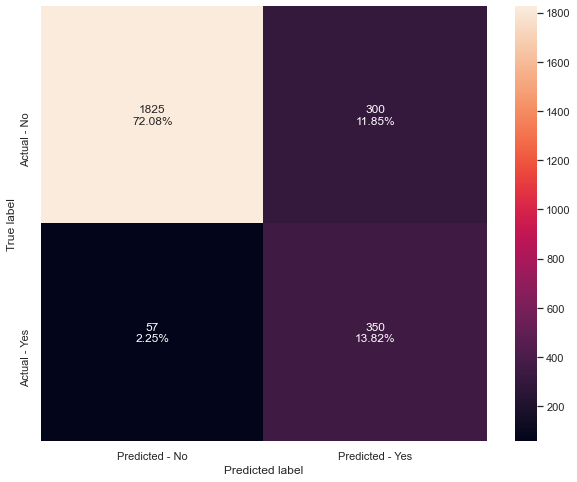

In [125]:
make_confusion_matrix(logit, X_val, y_val)

Observations:
- The logistic regression with class weight does a pretty good job.
- First of all, it does not overfit. Metrics of train and test data are quite close.
- `recall` on both train and test is 87% which is acceptable.
- `recision` in the contrary is very poor. The model wrongly classified as Attrited Customers 288 which were actually not, out of the 642 tat it classified as such, making therefore a 46.15% error.

### <a name = 'link422'>4.2.2. Decision Tree</a>

In [86]:
dTree = DecisionTreeClassifier(random_state=1)
dTree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [126]:
dTree_score = get_metrics_score2(dTree, X_train, X_val, y_train, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.931
Recall on training set :  1.0
Recall on validation set :  0.786
Precision on training set :  1.0
Precision on validation set :  0.786
F1 on training set :  1.0
F1 on validation set :  0.786


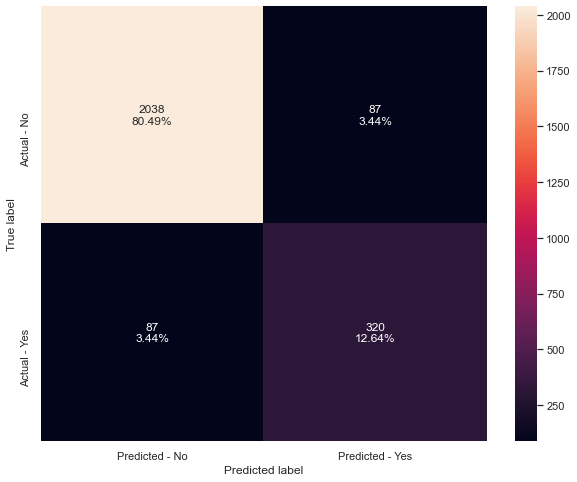

In [127]:
make_confusion_matrix(dTree, X_val, y_val)

Observations:
- Decision Tree overfits
- `precision` is better that that of Logistic regression but `recall` is a little less.

### <a name = 'link423'>4.2.3. Bagging Classifier </a>

In [89]:
bagging = BaggingClassifier(random_state=1)
bagging.fit(X_train, y_train)

BaggingClassifier(random_state=1)

In [128]:
bagging_score = get_metrics_score2(bagging, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.997
Accuracy on validation set :  0.952
Recall on training set :  0.985
Recall on validation set :  0.808
Precision on training set :  0.999
Precision on validation set :  0.884
F1 on training set :  0.992
F1 on validation set :  0.845


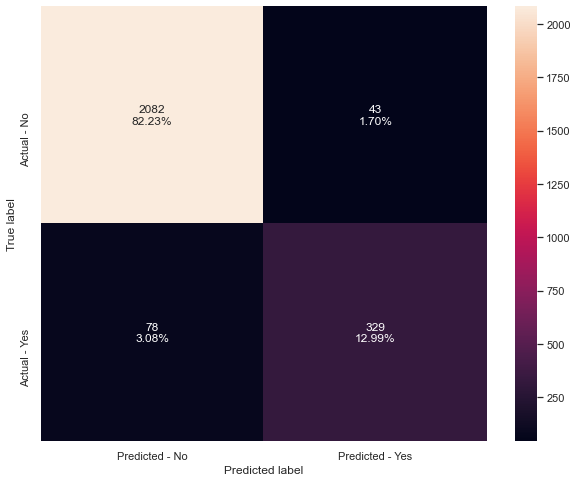

In [129]:
make_confusion_matrix(bagging, X_val, y_val)

Observation:
- Overfitting reduced as compared to Decision Tree.
- `precision`  has improved, but `recall` is still less than that of Logistic Regression.
- Model makes less error

### <a name = 'link424'>4.2.4. Random Forest Classifier</a>

In [92]:
rf = RandomForestClassifier(random_state=1)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=1)

In [130]:
rf_score = get_metrics_score2(rf, X_train, X_val, y_train, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.955
Recall on training set :  1.0
Recall on validation set :  0.794
Precision on training set :  1.0
Precision on validation set :  0.915
F1 on training set :  1.0
F1 on validation set :  0.85


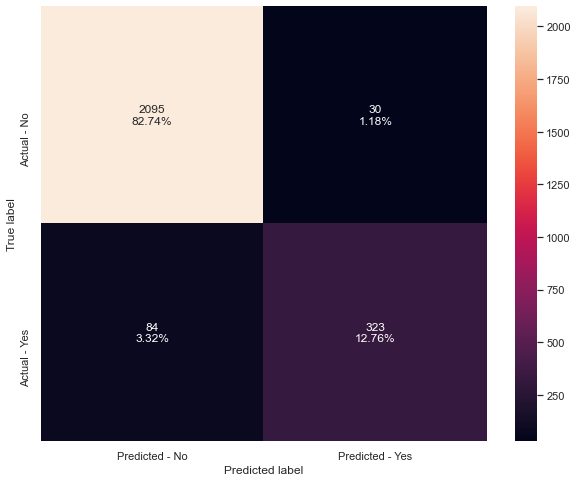

In [131]:
make_confusion_matrix(rf, X_val, y_val)

Observations:
- The model gives the best `precision` so far, but the less `recall` too.
- Besides, there is a slight overfitting.

### <a name = 'link425'>4.2.5. Adaptive Boosting</a>

In [95]:
adb = AdaBoostClassifier(
    random_state=1,
)
adb.fit(X_train, y_train)

AdaBoostClassifier(random_state=1)

In [132]:
adb_score = get_metrics_score2(adb, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.96
Accuracy on validation set :  0.956
Recall on training set :  0.85
Recall on validation set :  0.826
Precision on training set :  0.896
Precision on validation set :  0.894
F1 on training set :  0.872
F1 on validation set :  0.858


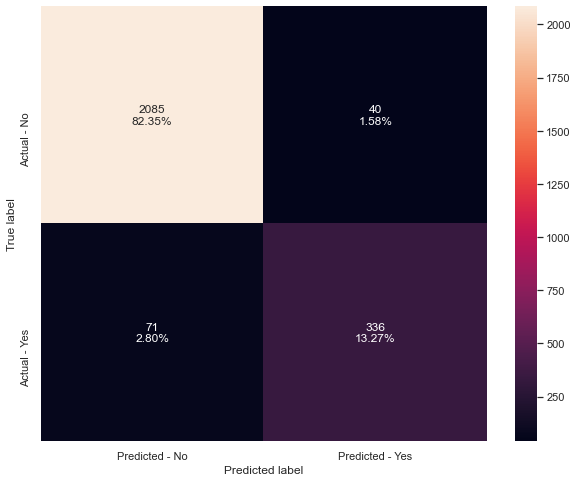

In [133]:
make_confusion_matrix(adb, X_val, y_val)

Observations:
- Model performances on training and validation data are very close, the model is not overfitting the training data.
- Good results overall with a `recall score` of 82.6% and `precision` of 89.4%

### <a name = 'link426'>4.2.6. Gradient Boosting</a>

In [98]:
gbm = GradientBoostingClassifier(random_state=1)
gbm.fit(X_train, y_train)

GradientBoostingClassifier(random_state=1)

In [134]:
gbm_score = get_metrics_score2(gbm, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.976
Accuracy on validation set :  0.965
Recall on training set :  0.892
Recall on validation set :  0.838
Precision on training set :  0.959
Precision on validation set :  0.939
F1 on training set :  0.924
F1 on validation set :  0.886


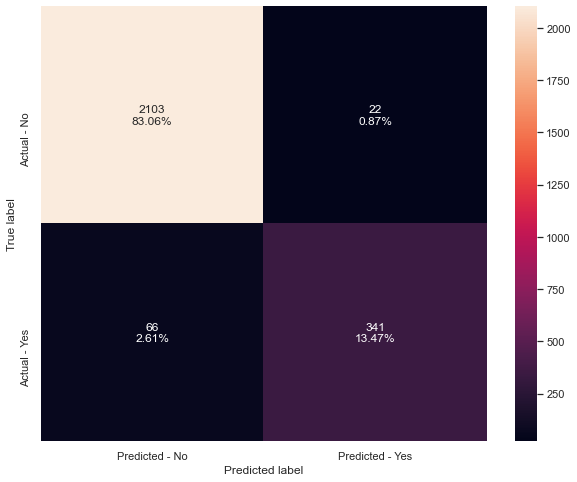

In [135]:
make_confusion_matrix(gbm, X_val, y_val)

- Model gives good perforances with a `recall` of 83.8%  and a `precision` of 93.9% on validation data.
- Performances on train and validation data are very similar, so there is no overfitting on training data.

### <a name = 'link427'>4.2.7. eXtreme Gradient Boosting</a>

In [101]:
xgb = XGBClassifier(random_state=1, eval_metric="logloss")
xgb.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, eval_metric='logloss',
              gamma=0, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.300000012,
              max_delta_step=0, max_depth=6, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=100, n_jobs=8,
              num_parallel_tree=1, random_state=1, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=1, subsample=1, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [136]:
xgb_score = get_metrics_score2(xgb, X_train, X_val, y_train, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.971
Recall on training set :  1.0
Recall on validation set :  0.887
Precision on training set :  1.0
Precision on validation set :  0.93
F1 on training set :  1.0
F1 on validation set :  0.908


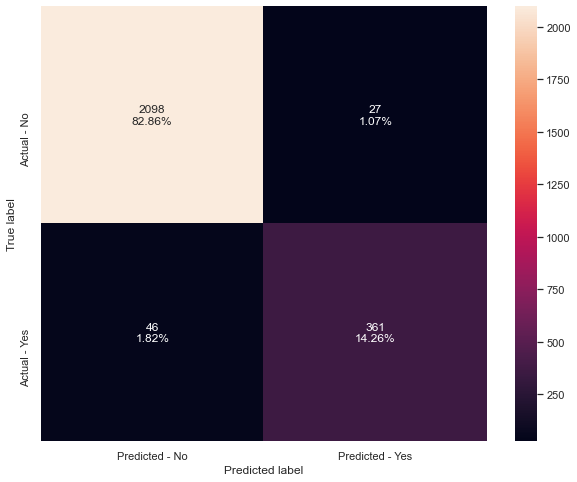

In [137]:
make_confusion_matrix(xgb, X_val, y_val)

Observation:
- Model gives the best results on test in any metric.

## <a name = 'link43'>4.3 Model building - Models tuning</a>

### <a name = 'link431'>4.3.1. Tuned Logistic Regression</a>

In [280]:
# Choose the classifier
LogR = LogisticRegression(random_state=1, class_weight={0: 0.16, 1: 0.84})

# Hyperparameters to tune

LogR_params_dist = {
    "C": np.arange(0, 2.001, 0.001)
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the random search
LogR_rand_search = RandomizedSearchCV(
    LogR,
    param_distributions=LogR_params_dist,
    n_iter=100,
    cv=10,
    scoring=scorer,
    random_state=1,
)

LogR_rand_search.fit(X_train, y_train)

RandomizedSearchCV(cv=10,
                   estimator=LogisticRegression(class_weight={0: 0.16, 1: 0.84},
                                                random_state=1),
                   n_iter=100,
                   param_distributions={'C': array([0.000e+00, 1.000e-03, 2.000e-03, ..., 1.998e+00, 1.999e+00,
       2.000e+00])},
                   random_state=1, scoring=make_scorer(recall_score))

In [281]:
tuned_logit = LogR_rand_search.best_estimator_
tuned_logit.fit(X_train, y_train)

LogisticRegression(C=0.421, class_weight={0: 0.16, 1: 0.84}, random_state=1)

In [282]:
tuned_logit_score = get_metrics_score2(tuned_logit, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.862
Accuracy on validation set :  0.859
Recall on training set :  0.871
Recall on validation set :  0.855
Precision on training set :  0.543
Precision on validation set :  0.538
F1 on training set :  0.669
F1 on validation set :  0.66


- Tuning the Logistic Regression did not result in any significant change in the erformance of the model. The model still does not overfit with acceptable `accuracy` and `recall` scores but quite low `precision`.

### <a name = 'link432'>4.3.2. Tuned Decision Tree</a>

In [162]:
# Choose the type of classifier. 
tree = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {'max_depth': randint(1,10), 
              'min_samples_leaf': randint(1,20),
              'max_leaf_nodes' : randint(1,20),
              "max_depth": randint(1,20),
              'min_impurity_decrease': np.arange(0,1,0.1),
              "max_features":randint(1,20)
             }

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.recall_score)

# Run the random search
random_searchs = RandomizedSearchCV(tree, parameters, scoring=acc_scorer,cv=10, n_iter=100, random_state=1)
random_searchs.fit(X_train, y_train)


RandomizedSearchCV(cv=10, estimator=DecisionTreeClassifier(random_state=1),
                   n_iter=100,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B8F1EAC40>,
                                        'max_features': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B92E400A0>,
                                        'max_leaf_nodes': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B92E401C0>,
                                        'min_impurity_decrease': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]),
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B92E402B0>},
                   random_state=1, scoring=make_scorer(recall_score))

In [163]:
# Parameters of the best model.
random_searchs.best_params_

{'max_depth': 15,
 'max_features': 9,
 'max_leaf_nodes': 8,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 6}

In [107]:
# Set the classifier to the best combination of parameters
tuned_tree = random_searchs.best_estimator_

# Fit the best algorithm to the data.
tuned_tree.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=15, max_features=9, max_leaf_nodes=8,
                       min_samples_leaf=6, random_state=1)

In [108]:
tuned_tree_score = get_metrics_score2(tuned_tree, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.907
Accuracy on validation set :  0.894
Recall on training set :  0.661
Recall on validation set :  0.624
Precision on training set :  0.734
Precision on validation set :  0.688
F1 on training set :  0.695
F1 on validation set :  0.655


Tuning Decision Tree results in reduction of overfitting, but lower performances on validation data.

### <a name = 'link433'>4.3.3. Tuned Bagging Classifier </a>

In [109]:
clfs = [
    DecisionTreeClassifier(random_state=1, class_weight={0: 0.16, 1: 0.84}),
    DecisionTreeClassifier(random_state=1),
]
param_dist = {
    "base_estimator": clfs,
    "n_estimators": randint(50, 250),
    "max_features": np.arange(0, 1.01, 0.1),
}
scorer = metrics.make_scorer(metrics.recall_score)

random_search = RandomizedSearchCV(
    BaggingClassifier(random_state=0, bootstrap=True),
    param_distributions=param_dist,
    scoring=scorer,
    cv=10,
    n_iter=100,
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=10, estimator=BaggingClassifier(random_state=0),
                   n_iter=100,
                   param_distributions={'base_estimator': [DecisionTreeClassifier(class_weight={0: 0.16,
                                                                                                1: 0.84},
                                                                                  random_state=1),
                                                           DecisionTreeClassifier(random_state=1)],
                                        'max_features': array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B980E2070>},
                   scoring=make_scorer(recall_score))

In [161]:
random_search.best_params_

{'base_estimator': DecisionTreeClassifier(random_state=1),
 'max_features': 1.0,
 'n_estimators': 141}

In [110]:
tuned_bagging = random_search.best_estimator_
tuned_bagging.fit(X_train, y_train)

BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=1),
                  n_estimators=141, random_state=0)

In [111]:
tuned_bagging_score = get_metrics_score2(tuned_bagging, X_train, X_val, y_train, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.959
Recall on training set :  1.0
Recall on validation set :  0.84
Precision on training set :  1.0
Precision on validation set :  0.895
F1 on training set :  1.0
F1 on validation set :  0.867


- Tuned Bagging Classifier gives better performance on validation data on all the metrics.

### <a name = 'link424'>4.3.4. Tuned Random Forest Classifier</a>

In [112]:
# Choose the type of classifier. 
rfc = RandomForestClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {  
        "n_estimators": randint(30,300),
        "min_samples_leaf": randint(1,10),
        "max_features": [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.9,1,'log2','auto'],
        #"ccp_alpha": np.arange(0,1,0.01),
        "max_depth":randint(1,100),
        "class_weight":['balanced', {0:.16,1:.84}, None],
        "max_samples": [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.9,1]
}

# Run the random search
randomized = RandomizedSearchCV(rfc, parameters, scoring='recall',cv=10, n_iter=100, random_state=0)
randomized.fit(X_train, y_train)


RandomizedSearchCV(cv=10, estimator=RandomForestClassifier(random_state=1),
                   n_iter=100,
                   param_distributions={'class_weight': ['balanced',
                                                         {0: 0.16, 1: 0.84},
                                                         None],
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B8F43C970>,
                                        'max_features': [0.1, 0.2, 0.3, 0.4,
                                                         0.5, 0.6, 0.7, 0.9, 1,
                                                         'log2', 'auto'],
                                        'max_samples': [0.1, 0.2, 0.3, 0.4, 0.5,
                                                        0.6, 0.7, 0.9, 1],
                                        'min_samples_leaf': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B90D6AD00>,
                               

In [160]:
# Best model parameters
randomized.best_params_

{'class_weight': 'balanced',
 'max_depth': 3,
 'max_features': 0.6,
 'max_samples': 0.6,
 'min_samples_leaf': 6,
 'n_estimators': 283}

In [113]:
# Set the classifier to the best combination of parameters
tuned_rf = randomized.best_estimator_

# Fit the best algorithm to the data.
tuned_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=3, max_features=0.6,
                       max_samples=0.6, min_samples_leaf=6, n_estimators=283,
                       random_state=1)

In [114]:
tuned_rf_score = get_metrics_score2(tuned_rf, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.866
Accuracy on validation set :  0.857
Recall on training set :  0.93
Recall on validation set :  0.904
Precision on training set :  0.549
Precision on validation set :  0.533
F1 on training set :  0.69
F1 on validation set :  0.67


- Tuned Random Forest does not overfits. It gives better `recall` than the untuned one, but lower result on the otherr metrics. `precision` on validation drops from above 90% to 53.3% and `F1 score` from 85% to 67%.

### <a name = 'link435'>4.3.5. Tuned Adaptive Boosting</a>

In [156]:
base = AdaBoostClassifier(random_state=1)
parameters = {
    #Let's try different max_depth for base_estimator
    "base_estimator":[DecisionTreeClassifier(random_state=1, class_weight={0:.16,1:.84}), DecisionTreeClassifier(max_depth=1, random_state=1, class_weight={0:.16,1:.84}),DecisionTreeClassifier(max_depth=2, random_state=1, class_weight={0:.16,1:.84}),
                      DecisionTreeClassifier(max_depth=3, random_state=1, class_weight={0:.16,1:.84}),DecisionTreeClassifier(random_state=1), DecisionTreeClassifier(max_depth=1, random_state=1),DecisionTreeClassifier(max_depth=2, random_state=1),
                      DecisionTreeClassifier(max_depth=3, random_state=1)],
    "n_estimators": randint(30,310),
    "learning_rate":np.arange(0.01,2,0.01)
}

# Type of scoring used to compare parameter  combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
random_object = RandomizedSearchCV(base,parameters, scoring=scorer,cv=10, n_iter=100, random_state=0)
random_object.fit(X_train, y_train)


RandomizedSearchCV(cv=10, estimator=AdaBoostClassifier(random_state=1),
                   n_iter=100,
                   param_distributions={'base_estimator': [DecisionTreeClassifier(class_weight={0: 0.16,
                                                                                                1: 0.84},
                                                                                  random_state=1),
                                                           DecisionTreeClassifier(class_weight={0: 0.16,
                                                                                                1: 0.84},
                                                                                  max_depth=1,
                                                                                  random_state=1),
                                                           DecisionTreeClassifier(class_weight={0: 0.16,
                                                                             

In [157]:
random_object.best_params_

{'base_estimator': DecisionTreeClassifier(class_weight={0: 0.16, 1: 0.84}, max_depth=2,
                        random_state=1),
 'learning_rate': 0.04,
 'n_estimators': 264}

In [158]:
# Set the best combination of parameters
tuned_adb = random_object.best_estimator_

# Fit the best algorithm to the data.
tuned_adb.fit(X_train, y_train)


AdaBoostClassifier(base_estimator=DecisionTreeClassifier(class_weight={0: 0.16,
                                                                       1: 0.84},
                                                         max_depth=2,
                                                         random_state=1),
                   learning_rate=0.04, n_estimators=264, random_state=1)

In [159]:
tuned_adb_score = get_metrics_score2(tuned_adb, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.955
Accuracy on validation set :  0.943
Recall on training set :  0.979
Recall on validation set :  0.941
Precision on training set :  0.792
Precision on validation set :  0.761
F1 on training set :  0.876
F1 on validation set :  0.842


Tuned AdaBoost gives similar scores on `accuracy`, `precision` and `F1 score`. On the contrary, compared to the untuned model, it improves `recall` from 82.6%  to 94.1 on validation data.

### <a name = 'link436'>4.3.6. Tuned Gradient Boosting</a>

In [118]:
# Choose the type of classifier. 
gbm_t = GradientBoostingClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "n_estimators": randint(20, 300),
    "subsample":[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1],
    "max_depth": randint(1,31),
    "max_features":randint(1,21),
    "learning_rate":np.arange(0, 1.01,.01)
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
random_obj = RandomizedSearchCV(gbm_t, parameters, scoring=scorer,cv=10, n_iter=100, random_state=1)
random_obj.fit(X_train, y_train)


RandomizedSearchCV(cv=10, estimator=GradientBoostingClassifier(random_state=1),
                   n_iter=100,
                   param_distributions={'learning_rate': array([0.  , 0.01, 0.02, 0.03, 0.04, 0.05, 0.06, 0.07, 0.08, 0.09, 0.1 ,
       0.11, 0.12, 0.13, 0.14, 0.15, 0.16, 0.17, 0.18, 0.19, 0.2 , 0.21,
       0.22, 0.23, 0.24, 0.25, 0.26, 0.27, 0.28, 0.29, 0.3 , 0.31, 0.32,
       0.33, 0.34, 0.35, 0.36, 0.37, 0.38, 0.39, 0.4 , 0.41, 0.42, 0.43,
       0.4...
                                        'max_depth': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B97EDAA90>,
                                        'max_features': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B8F3AE640>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B8F3AEE20>,
                                        'subsample': [0.1, 0.2, 0.3, 0.4, 0.5,
                                                      

In [154]:
random_obj.best_params_

{'learning_rate': 0.34,
 'max_depth': 3,
 'max_features': 11,
 'n_estimators': 230,
 'subsample': 0.7}

In [119]:
# Get the best combination of parameters
tuned_gbm = random_obj.best_estimator_

# Fit the best algorithm to the data.
tuned_gbm.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.34, max_features=11,
                           n_estimators=230, random_state=1, subsample=0.7)

In [120]:
tuned_gbm_score = get_metrics_score2(tuned_gbm, X_train, X_val, y_train, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.97
Recall on training set :  1.0
Recall on validation set :  0.894
Precision on training set :  1.0
Precision on validation set :  0.917
F1 on training set :  1.0
F1 on validation set :  0.905


- Tuned Gradient Boosting overfits slightly but it is still fine.
- Apart from a slight decrease in `precision`, all other metrics performances have increased.

### <a name = 'link437'>4.3.7. Tuned eXtreme Gradient Boosting</a>

In [121]:
# Choose the type of classifier.
xgb_h = XGBClassifier(random_state=1, eval_metric="logloss")

# Grid of parameters to choose from
parameters = {
    "n_estimators": randint(20, 301),
    "scale_pos_weight": randint(1, 21),
    "max_depth": randint(1,31),
    "n_jobs": randint(1, 21),
    "subsample": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    "learning_rate": np.arange(0, 1.01,.01),
    "colsample_bytree": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
    "colsample_bylevel": [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1],
}

# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

# Run the grid search
rand_search = RandomizedSearchCV(
    xgb_h, parameters, scoring=scorer, cv=10, n_iter=100, random_state=1
)
rand_search.fit(X_train, y_train)


RandomizedSearchCV(cv=10,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None,
                                           eval_metric='logloss', gamma=None,
                                           gpu_id=None, importance_type='gain',
                                           interaction_constraints=None,
                                           learning_rate=None,
                                           max_delta_step=None, max_depth=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints...
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_frozen object at 0x0000011B8EA5EFA0>,
                                        'n_jobs':

In [153]:
xgb_best_params = rand_search.best_params_
xgb_best_params

{'colsample_bylevel': 0.9,
 'colsample_bytree': 0.8,
 'learning_rate': 0.55,
 'max_depth': 2,
 'n_estimators': 279,
 'n_jobs': 1,
 'scale_pos_weight': 14,
 'subsample': 0.7}

In [122]:
tuned_xgb = rand_search.best_estimator_
tuned_xgb.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=0.9,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              gamma=0, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.55, max_delta_step=0,
              max_depth=2, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=279, n_jobs=1,
              num_parallel_tree=1, random_state=1, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=14, subsample=0.7, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [123]:
tuned_xgb_score = get_metrics_score2(tuned_xgb, X_train, X_val, y_train, y_val)

Accuracy on training set :  0.992
Accuracy on validation set :  0.962
Recall on training set :  1.0
Recall on validation set :  0.916
Precision on training set :  0.955
Precision on validation set :  0.856
F1 on training set :  0.977
F1 on validation set :  0.885


- Tuning XGBoost reduces overfitting and increases `recall` but decreases slightly other metrics.

## <a name = 'link44'>4.4. Building Model - Oversampled data</a>

### <a name = 'link441'>4.4.1 Building Model - Oversampled data using SMOTE</a>

We perform the oversampling of the minority class here using the Synthetic Minority Oversampling TEchnique aka SMOTE

In [152]:
print("Before UpSampling, counts of label 'Existing Customer' is: {}".format(len(y_train[y_train['Attrition_Flag'] == 0])))
print("Before UpSampling, counts of label 'Attrited Customer' is: {} \n".format(len(y_train[y_train['Attrition_Flag'] == 1])))

sm = SMOTE(
    sampling_strategy=1, k_neighbors=5, random_state=1
) 
X_train_os, y_train_os = sm.fit_resample(X_train, y_train)


print("After UpSampling, counts of label 'Existing Customer': {}".format(len(y_train_os[y_train_os['Attrition_Flag'] == 0])))
print("After UpSampling, counts of label 'Attrited Customer': {} \n".format(len(y_train_os[y_train_os['Attrition_Flag'] == 1])))


print("After UpSampling, the shape of train_X: {}".format(X_train_os.shape))
print("After UpSampling, the shape of train_y: {} \n".format(y_train_os.shape))

Before UpSampling, counts of label 'Existing Customer' is: 4250
Before UpSampling, counts of label 'Attrited Customer' is: 813 

After UpSampling, counts of label 'Existing Customer': 4250
After UpSampling, counts of label 'Attrited Customer': 4250 

After UpSampling, the shape of train_X: (8500, 20)
After UpSampling, the shape of train_y: (8500, 1) 



### Fitting Tuned Bagging Classifier

In [168]:
bagging_os = BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=1), max_features=1, n_estimators=141, 
                               random_state=1)
bagging_os.fit(X_train_os, y_train_os)

BaggingClassifier(base_estimator=DecisionTreeClassifier(random_state=1),
                  max_features=1, n_estimators=141, random_state=1)

In [169]:
bagging_os_score = get_metrics_score2(bagging_os, X_train_os, X_val, y_train_os, y_val)

Accuracy on training set :  0.924
Accuracy on validation set :  0.277
Recall on training set :  0.848
Recall on validation set :  0.993
Precision on training set :  1.0
Precision on validation set :  0.181
F1 on training set :  0.918
F1 on validation set :  0.306


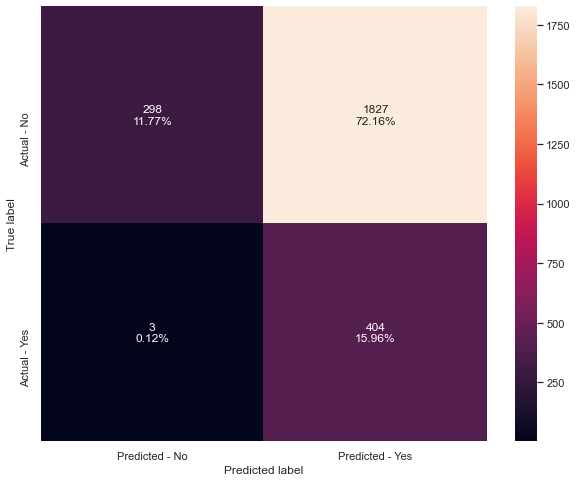

In [285]:
make_confusion_matrix(bagging_os, X_val, y_val)

### Fitting AdaBoost Classifier

In [243]:
adb_os = AdaBoostClassifier(base_estimator= DecisionTreeClassifier(max_depth=2,
                        random_state=1), learning_rate= 0.04, n_estimators= 264, random_state=1)
adb_os.fit(X_train_os, y_train_os)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2,
                                                         random_state=1),
                   learning_rate=0.04, n_estimators=264, random_state=1)

In [244]:
adb_os_score = get_metrics_score2(adb_os, X_train_os, X_val, y_train_os, y_val)

Accuracy on training set :  0.98
Accuracy on validation set :  0.826
Recall on training set :  0.977
Recall on validation set :  0.946
Precision on training set :  0.982
Precision on validation set :  0.479
F1 on training set :  0.98
F1 on validation set :  0.636


- Fitting Tuned AdaBoost on oversampled data (oversampling with SMOTE) gives greater performance on training data than on original training data. However, this good training performance is not replicating on validation data, especially in terms of `accuracy` and `precision`. 
- The model fitted with original data gives an `accuracy` score on validation data of 94.3% versus only 82.6% for the model fitted with SMOTE oversampled data.
- `precision` was 76.1% on validation data with model fitted on original training data , it drops to 47.9% with the actual model.

### Fitting Tuned Gradient Boosting Classifier

In [174]:
gbm_os = GradientBoostingClassifier(learning_rate=0.34, max_features=11,
                           n_estimators=230, random_state=1, subsample=0.7)
gbm_os.fit(X_train_os, y_train_os)

GradientBoostingClassifier(learning_rate=0.34, max_features=11,
                           n_estimators=230, random_state=1, subsample=0.7)

In [175]:
gbm_os_score = get_metrics_score2(gbm_os, X_train_os, X_val, y_train_os, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.944
Recall on training set :  1.0
Recall on validation set :  0.939
Precision on training set :  1.0
Precision on validation set :  0.766
F1 on training set :  1.0
F1 on validation set :  0.843


The same scenario with AdaBoost happens here. Model fitted with original data performs better on validation in terms of `recall` and `precision`.

### Fitting Tuned XGBoost Classifier

In [176]:
xgb_os = XGBClassifier(base_score=0.5, colsample_bylevel=0.9,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              learning_rate=0.55,
              max_depth=2, n_estimators=279, random_state=1,
              scale_pos_weight=14, subsample=0.7)
xgb_os.fit(X_train_os, y_train_os)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=0.9,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              gamma=0, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.55, max_delta_step=0,
              max_depth=2, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=279, n_jobs=8,
              num_parallel_tree=1, random_state=1, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=14, subsample=0.7, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [177]:
xgb_os_score = get_metrics_score2(xgb_os, X_train_os, X_val, y_train_os, y_val)

Accuracy on training set :  0.993
Accuracy on validation set :  0.906
Recall on training set :  1.0
Recall on validation set :  0.953
Precision on training set :  0.987
Precision on validation set :  0.64
F1 on training set :  0.993
F1 on validation set :  0.766


The same observations we did on the two previous models hold here. While doing better on training data, the model fails to replicate that good performance on validation data for `accuracy` and `precision` as compared to the model fitted with original data.

**A note of summary**:

- The models fitted with (SMOTE) oversampled data all perform good on training. Their `recalll` performance on validation data are all better than those of models fitted with original data. At the their `accuracy` and `precision` dropped, with a drastic drop on `precision`.

- Given the obervation above, we are going to fit the same classifiers to oversampled data where the new observations are replicates of original ones, that is we are going to use RandomOverSampler. We will compare to see if the behavior is different.

### <a name = 'link442'>4.4.2 Building Model - Oversampled data using RandomOverSampler</a>

### Sampling using RandomOverSampler

In [252]:
ros = RandomUnderSampler(random_state=1)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

### Fitting Tuned AdaBoostClassifier

In [253]:
adb_ros = AdaBoostClassifier(base_estimator= DecisionTreeClassifier(max_depth=2,
                        random_state=1), learning_rate= 0.04, n_estimators= 264, random_state=1)
adb_ros.fit(X_train_ros, y_train_ros)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2,
                                                         random_state=1),
                   learning_rate=0.04, n_estimators=264, random_state=1)

In [254]:
adb_ros_score = get_metrics_score2(adb_ros, X_train_ros, X_val, y_train_ros, y_val)

Accuracy on training set :  0.972
Accuracy on validation set :  0.928
Recall on training set :  0.978
Recall on validation set :  0.943
Precision on training set :  0.966
Precision on validation set :  0.707
F1 on training set :  0.972
F1 on validation set :  0.808


`accuracy` and `precision` have improved compared to model with SMOTE data. `recall` has not changed

### Fitting Tuned GradientBoostingClassifier

In [255]:
gbm_ros = GradientBoostingClassifier(learning_rate=0.34, max_features=11,
                           n_estimators=230, random_state=1, subsample=0.7)
gbm_ros.fit(X_train_ros, y_train_ros)

GradientBoostingClassifier(learning_rate=0.34, max_features=11,
                           n_estimators=230, random_state=1, subsample=0.7)

In [256]:
gbm_ros_score = get_metrics_score2(gbm_ros, X_train_ros, X_val, y_train_ros, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.946
Recall on training set :  1.0
Recall on validation set :  0.953
Precision on training set :  1.0
Precision on validation set :  0.767
F1 on training set :  1.0
F1 on validation set :  0.85


For Gradient Boosting, `accuracy` and `precision` are still a little lower that those of the model with original data, and the have not improved compared to the model with SMOTE data.

### Fitting Tuned XGBClassifier

In [257]:
xgb_ros = XGBClassifier(base_score=0.5, colsample_bylevel=0.9,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              learning_rate=0.55,
              max_depth=2, n_estimators=279, random_state=1,
              scale_pos_weight=14, subsample=0.7)
xgb_ros.fit(X_train_ros, y_train_ros)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=0.9,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              gamma=0, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.55, max_delta_step=0,
              max_depth=2, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=279, n_jobs=8,
              num_parallel_tree=1, random_state=1, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=14, subsample=0.7, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [258]:
xgb_ros_score = get_metrics_score2(xgb_ros, X_train_ros, X_val, y_train_ros, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.921
Recall on training set :  1.0
Recall on validation set :  0.961
Precision on training set :  1.0
Precision on validation set :  0.679
F1 on training set :  1.0
F1 on validation set :  0.796


XGBoost has improved as compared to model with SMOTE data but not the model with original data execpt for `recall`.

## <a name = 'link45'>4.5. Building Model - Undersampled data</a>

### Sampling to balance the data

We use `RandomUndersampler` technique to remove some observations of the majority class so as to balance our data.

In [164]:
rus = RandomUnderSampler(random_state=1)
X_train_us, y_train_us = rus.fit_resample(X_train, y_train)

In [165]:
print("Before UpSampling, counts of label 'Existing Customer' is: {}".format(len(y_train[y_train['Attrition_Flag'] == 0])))
print("Before UpSampling, counts of label 'Attrited Customer' is: {} \n".format(len(y_train[y_train['Attrition_Flag'] == 1])))

print("After UpSampling, counts of label 'Existing Customer': {}".format(len(y_train_us[y_train_us['Attrition_Flag'] == 0])))
print("After UpSampling, counts of label 'Attrited Customer': {} \n".format(len(y_train_us[y_train_us['Attrition_Flag'] == 1])))

print("After UpSampling, the shape of train_X: {}".format(X_train_us.shape))
print("After UpSampling, the shape of train_y: {} \n".format(y_train_us.shape))

Before UpSampling, counts of label 'Existing Customer' is: 4250
Before UpSampling, counts of label 'Attrited Customer' is: 813 

After UpSampling, counts of label 'Existing Customer': 813
After UpSampling, counts of label 'Attrited Customer': 813 

After UpSampling, the shape of train_X: (1626, 20)
After UpSampling, the shape of train_y: (1626, 1) 



Balancing has been performed. Now, we are going to fit some of the models we tuned aboved. We will choose those that performed the best.

### Fitting AdaBoostClassifier

In [245]:
adb_us = AdaBoostClassifier(base_estimator= DecisionTreeClassifier(max_depth=2,
                        random_state=1), learning_rate= 0.04, n_estimators= 264, random_state=1)
adb_us.fit(X_train_us, y_train_us)

AdaBoostClassifier(base_estimator=DecisionTreeClassifier(max_depth=2,
                                                         random_state=1),
                   learning_rate=0.04, n_estimators=264, random_state=1)

In [246]:
adb_us_score = get_metrics_score2(adb_us, X_train_us, X_val, y_train_us, y_val)

Accuracy on training set :  0.972
Accuracy on validation set :  0.928
Recall on training set :  0.978
Recall on validation set :  0.943
Precision on training set :  0.966
Precision on validation set :  0.707
F1 on training set :  0.972
F1 on validation set :  0.808


- The model gives similar results as with the RandomOverSampled data.
- Overall performance is satisfactory.
- The model does not overfit.

### Fitting GradientBoostingClassifier

In [247]:
gbm_us = GradientBoostingClassifier(learning_rate=0.34, max_features=11,
                           n_estimators=230, random_state=1, subsample=0.7)
gbm_us.fit(X_train_us, y_train_us)

GradientBoostingClassifier(learning_rate=0.34, max_features=11,
                           n_estimators=230, random_state=1, subsample=0.7)

In [248]:
gbm_us_score = get_metrics_score2(gbm_us, X_train_us, X_val, y_train_us, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.946
Recall on training set :  1.0
Recall on validation set :  0.953
Precision on training set :  1.0
Precision on validation set :  0.767
F1 on training set :  1.0
F1 on validation set :  0.85


- Gradient Boosting is having good performance overall on the validation data.

### Fitting XGBClassifier

In [249]:
xgb_us = XGBClassifier(base_score=0.5, colsample_bylevel=0.9,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              learning_rate=0.55,
              max_depth=2, n_estimators=279, random_state=1,
              scale_pos_weight=14, subsample=0.7)
xgb_us.fit(X_train_us, y_train_us)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=0.9,
              colsample_bynode=1, colsample_bytree=0.8, eval_metric='logloss',
              gamma=0, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.55, max_delta_step=0,
              max_depth=2, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=279, n_jobs=8,
              num_parallel_tree=1, random_state=1, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=14, subsample=0.7, tree_method='exact',
              validate_parameters=1, verbosity=None)

In [250]:
xgb_us_score = get_metrics_score2(xgb_us, X_train_us, X_val, y_train_us, y_val)

Accuracy on training set :  1.0
Accuracy on validation set :  0.921
Recall on training set :  1.0
Recall on validation set :  0.961
Precision on training set :  1.0
Precision on validation set :  0.679
F1 on training set :  1.0
F1 on validation set :  0.796


- Model has a good performance. Slightly higher `recall` on validation data as comperd to the previous ones. However, the `precision` is lower, but still fine.

**A note of summary**

Models with undersampled (RandomUnderSampler) data and those with oversampled (RandomOverSampler) data have the exact same performances.

## <a name = 'link46'>4.6. Model performances comparison</a>

In [292]:
# defining list of models
models = [tuned_adb, tuned_gbm, tuned_xgb, adb_os, gbm_os, xgb_os, adb_ros, gbm_ros, xgb_ros, adb_us, gbm_us, xgb_us]

# defining empty lists to add train and test results
acc_train = []
acc_val = []
recall_train = []
recall_val = []
precision_train = []
precision_val = []
f1_train = [] 
f1_val = []

# looping through all the models to get the metrics score - Accuracy, Recall and Precision
for model in models:
    if model in [tuned_adb, tuned_gbm, tuned_xgb]:
        scores = get_metrics_score(model,X_train, X_val, y_train, y_val)
    elif model in [adb_os, gbm_os, xgb_os]:
        scores = get_metrics_score(model,X_train_os, X_val, y_train_os, y_val)
    elif model in [adb_ros, gbm_ros, xgb_ros]:
        scores = get_metrics_score(model,X_train_ros, X_val, y_train_ros, y_val)
    else:
        scores = get_metrics_score(model,X_train_us, X_val, y_train_us, y_val)
    acc_train.append(scores[0])
    acc_val.append(scores[1])
    recall_train.append(scores[2])
    recall_val.append(scores[3])
    precision_train.append(scores[4])
    precision_val.append(scores[5])
    f1_train.append(scores[6])
    f1_val.append(scores[7])

In [293]:
comparison_frame = pd.DataFrame({'Model':['AdaBoost Original data','Gradient Boosting Original data', 'XGBoost Original data', 
                                          'Adaboost SMOTE', 'Gradient Boosting SMOTE',
                                          'XGBoost SMOTE', 'AdaBoost RandomOverSampler', 
                                          'Gradient Boosting RandomOverSampler','XGBoost RandomOverSampler',
                                          'AdaBoost UnderSampled data',
                                          'Gradient Boosting UnderSampled data', 'XGBoost UnderSampled data'], 
                                          'Train_Accuracy': acc_train,'Validation_Accuracy': acc_val,
                                          'Train_Recall':recall_train,'Validation_Recall':recall_val,
                                          'Train_Precision':precision_train,'Validation_Precision':precision_val,
                                           'Train_F1-Score':f1_train, 'Validation_F1-Score':f1_val}) 

#Sorting models in decreasing order of test recall
comparison_frame.sort_values(by='Validation_Recall',ascending=False)

,Model,Train_Accuracy,Validation_Accuracy,Train_Recall,Validation_Recall,Train_Precision,Validation_Precision,Train_F1-Score,Validation_F1-Score
8,XGBoost RandomOverSampler,1.000,0.921,1.000,0.961,1.000,0.679,1.000,0.796
11,XGBoost UnderSampled data,1.000,0.921,1.000,0.961,1.000,0.679,1.000,0.796
5,XGBoost SMOTE,0.993,0.906,1.000,0.953,0.987,0.640,0.993,0.766
7,Gradient Boosting RandomOverSampler,1.000,0.946,1.000,0.953,1.000,0.767,1.000,0.850
10,Gradient Boosting UnderSampled data,1.000,0.946,1.000,0.953,1.000,0.767,1.000,0.850
3,Adaboost SMOTE,0.980,0.826,0.977,0.946,0.982,0.479,0.980,0.636
6,AdaBoost RandomOverSampler,0.972,0.928,0.978,0.943,0.966,0.707,0.972,0.808
9,AdaBoost UnderSampled data,0.972,0.928,0.978,0.943,0.966,0.707,0.972,0.808
0,AdaBoost Original data,0.955,0.943,0.979,0.941,0.792,0.761,0.876,0.842
4,Gradient Boosting SMOTE,1.000,0.944,1.000,0.939,1.000,0.766,1.000,0.843


**Observations:**
- The best performing models are the one fitted on balanced data.
- For each type of classifier, model fitted with random samply (RandomOverSampler and RandomUnderSampler) perform the best.
- XGBoost on balanced data have the highest `recall` scores, but not so good `precision`.
- The models that give a `recall` > 0.95, an `accuracy`> 0.7 and a `precision` > 0.7 are Gradient Boosting with RandomOverSampler and RandomUderSampler. Since they have the exact same performances, we choose the model with RandomOverSampler as our best model.

### Testing our best model on test data

In [297]:
test_gbm_ros = get_metrics_score3(gbm_ros, X_test, y_test)

Accuracy on test set :  0.949
Recall on test set :  0.963
Precision on test set :  0.775
F1 on test set :  0.859


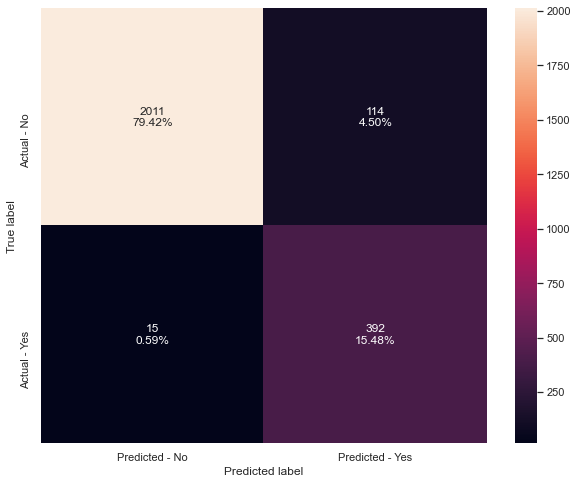

In [301]:
make_confusion_matrix(gbm_ros, X_test, y_test)

- Model performs great on test data.
- `recall` is 96.3% what is higher than the ones achieved on validation data.
- `precision` is 77.5% and `accuracy` is 94.9%.
- Out of the 407 attrited customers in the data set, the model identified 392 which is a very good score despite the fact it wrongly identified 114 Existing customers as Attrited ones.

### Feature Importances

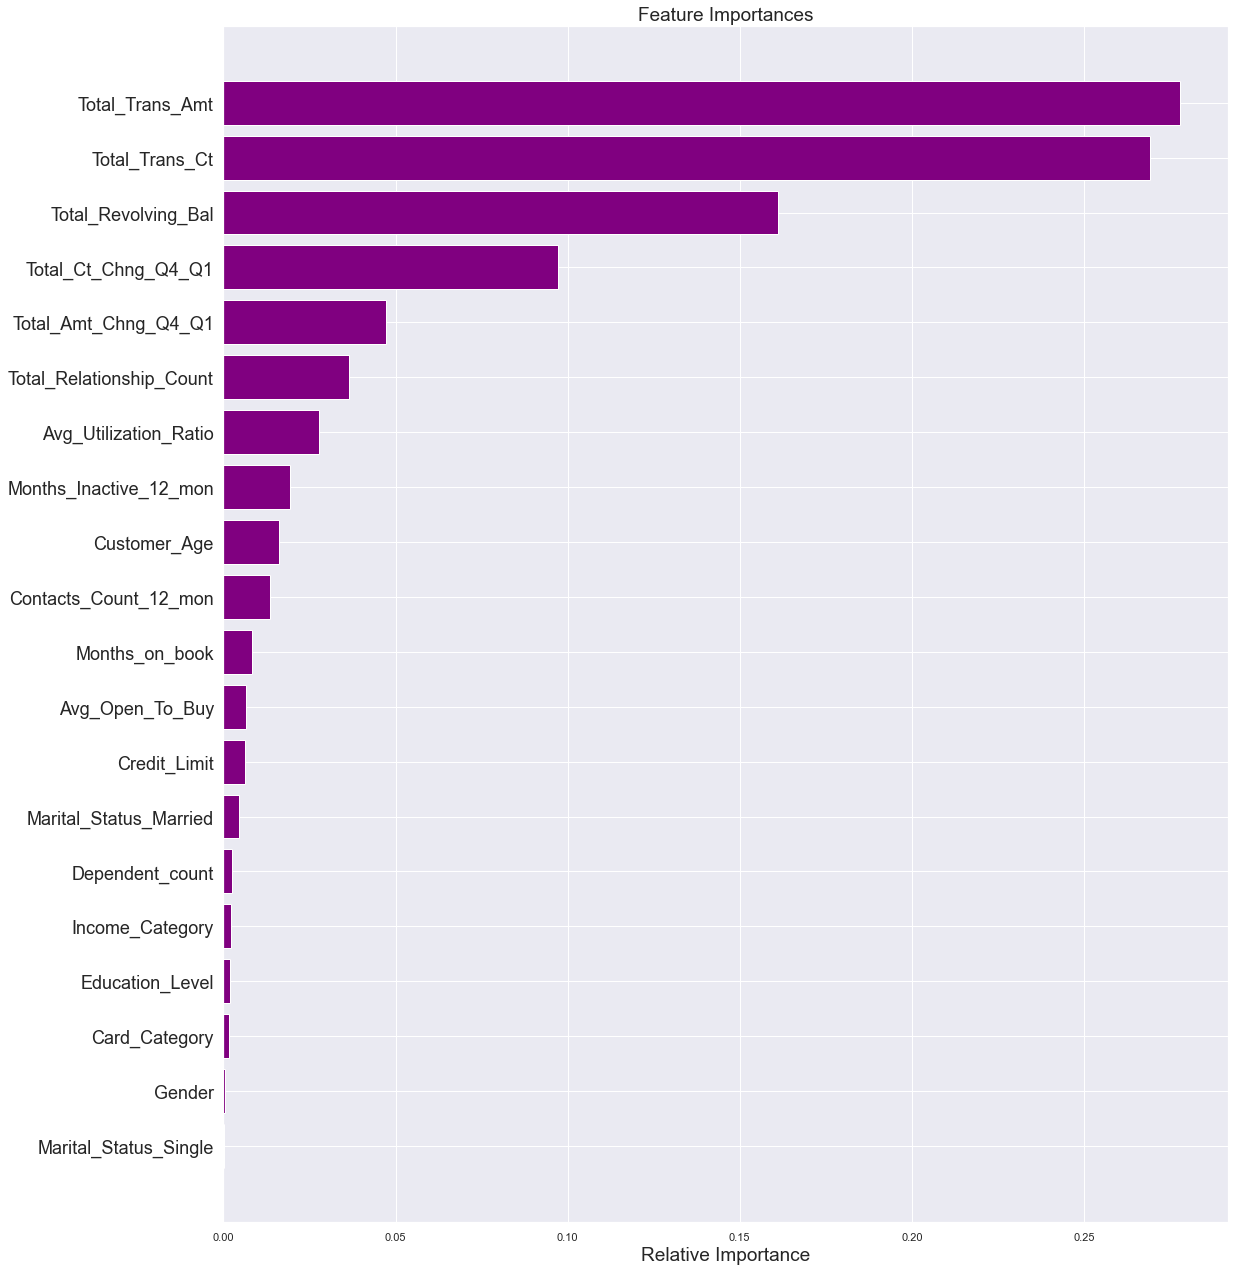

<IPython.core.display.Javascript object>

In [439]:
importances = gbm_ros.feature_importances_
indices = np.argsort(importances)
feature_names = list(X_train.columns)

plt.figure(figsize=(18, 22))
plt.title("Feature Importances", size=19)
plt.barh(range(len(indices)), importances[indices], color="purple", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices], size=18)
plt.xlabel("Relative Importance", size=19)
plt.show()

In [318]:
sum(sorted(importances, reverse=True)[:2])

0.5471073563182034

- Two features, `Total_Trans_Amt` and `Total_Trans_Ct`, contribute for more than 50% oin the model's prediction.
- The 5 most important feautures contributed for over 85% of the model's prediction. They are :`Total_Trans_Amt`, `Total_Trans_Ct`, `Total_Revolving_Bal`, `Total_Ct_Chng_Q4_Q1` and `Total_Amt_Chng_Q4_Q1`


## Testing another good model

From the chart above (in wihich we compare models' metrics), we can see that, even though it doesn't reachthe desired threshold in terms of `recall`, the tuned AdaBoost fitted to RandomOverSampled data is also a pretty good model with less overfitting. We are going to test it on test data and also plot the feature importances to see if there is a diffrences in feature importances with Gradient Boosting, our best performing (that fulfills the conditions specified) model.

In [431]:
adb_test_scores = get_metrics_score3(adb_ros, X_test, y_test)

Accuracy on test set :  0.932
Recall on test set :  0.966
Precision on test set :  0.712
F1 on test set :  0.82


<IPython.core.display.Javascript object>

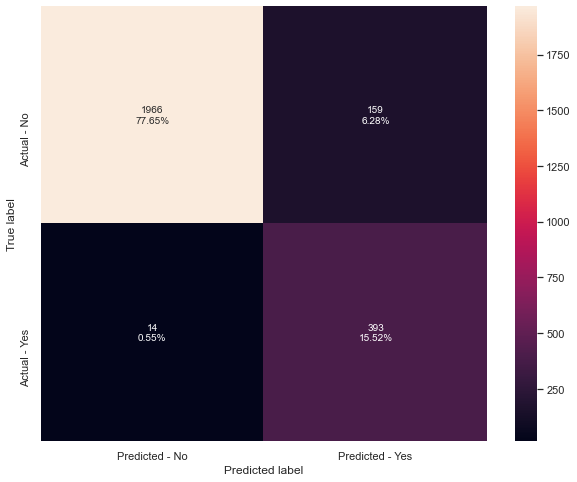

<IPython.core.display.Javascript object>

In [432]:
make_confusion_matrix(adb_ros, X_test, y_test)

Model performs pretty good on test data. Prediction performances are not to far from the ones of the above Gradient Boosting model.

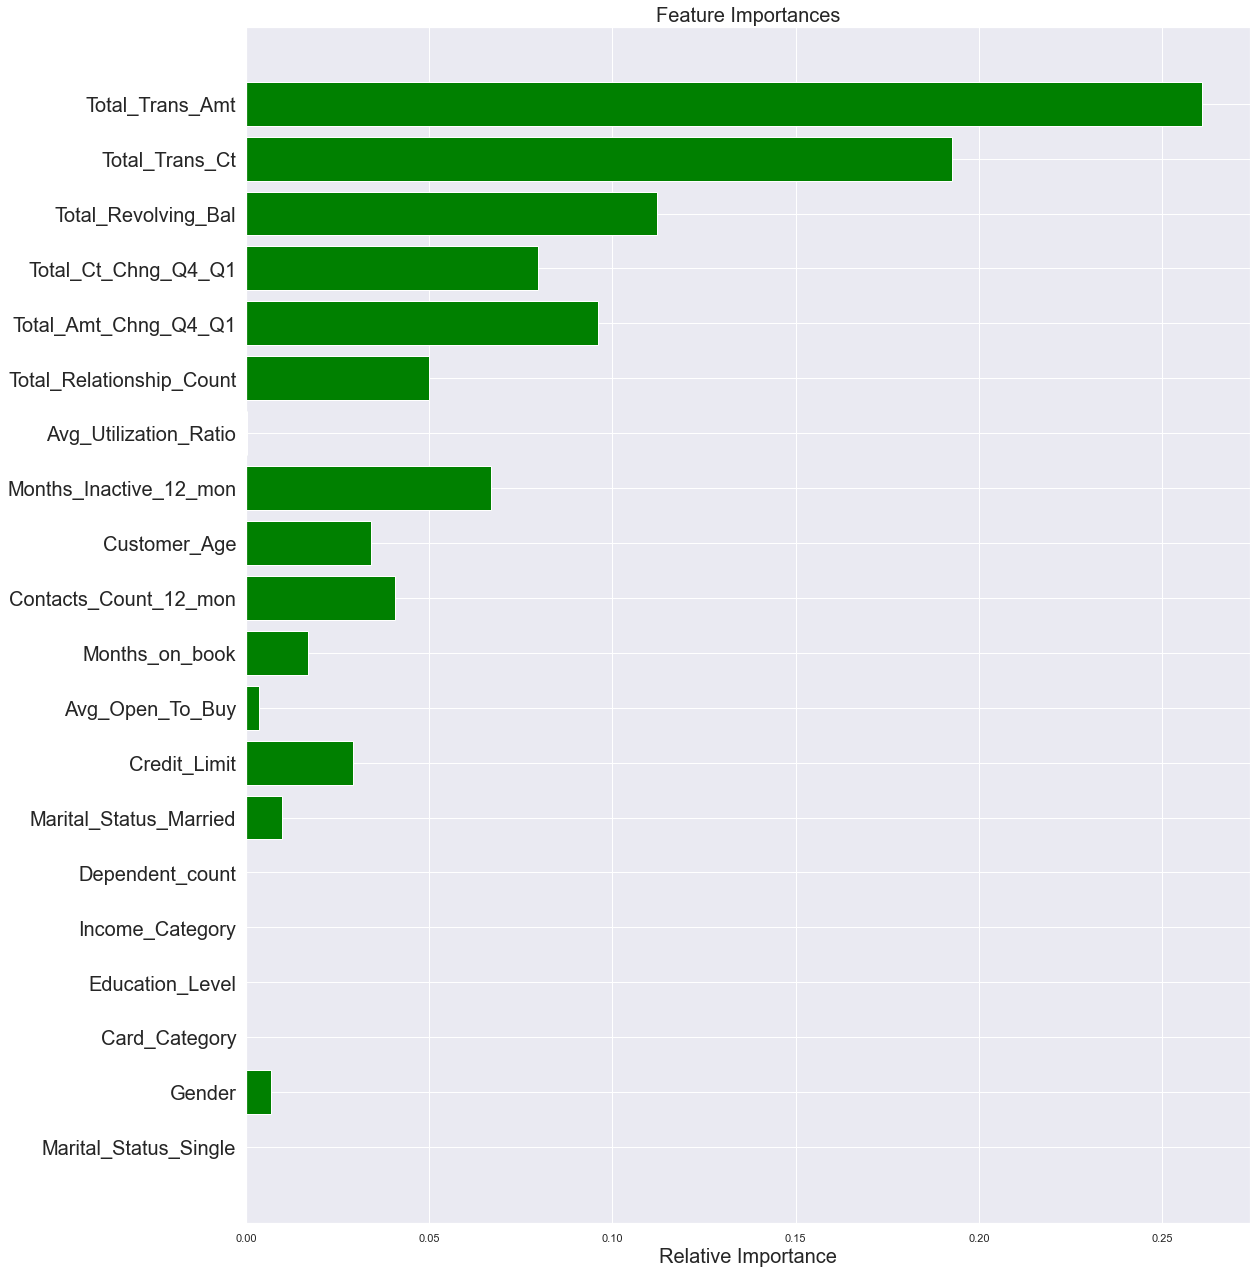

<IPython.core.display.Javascript object>

In [440]:
importancs = adb_ros.feature_importances_
indics = np.argsort(importances)
feature_nams = list(X_train.columns)

plt.figure(figsize=(18, 22))
plt.title("Feature Importances", size=20)
plt.barh(range(len(indics)), importancs[indics], color="green", align="center")
plt.yticks(range(len(indices)), [feature_nams[i] for i in indics], size=20)
plt.xlabel("Relative Importance", size=20)
plt.show()

Model uses the same features for prediction as the Gradient Boosting model. The same five features, in the same oreder as above contribute for over 70% in the predictions. This shows that theese features are indeen the one most important for attrition prediction.

## <a name = 'link47'>4.7. Pipeline construction to productionize the model</a>

Now that we have found the best model that works for us, we are going to built a pipeline to automate it.

In [428]:
# Let's start by the standardization of columns with continious values.

num_transf = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("standardization", StandardScaler()),
    ]
)

# Make the list of categorical features

cat_cols = [
    "Education_Level",
    "Income_Category",
    "Card_Category",
    "Gender",
    "Marital_Status",
]

# Transformations to perform on categorical columns

cat_transf = Pipeline(
    [("imputer", SimpleImputer(strategy="most_frequent")), ("enc", OneHotEncoder())]
)

# Combiming the two transformers above

col_process = ColumnTransformer(
    transformers=[
        ("numerical", num_transf, num_cols),
        ("cat", cat_transf, cat_cols),
    ],
    remainder="passthrough",
)

<IPython.core.display.Javascript object>

In [429]:
# Making a copy of the raw data

df = data.copy()

# Separate features and target

target = df[["Attrition_Flag"]]

features = df.drop(columns=["Attrition_Flag"])

# Split the data into train and test

train_X, test_X, train_y, test_y = train_test_split(
    features, target, test_size=0.3, stratify=target
)

<IPython.core.display.Javascript object>

In [430]:
# Pipeline construction for model automation

model = Pipeline(
    [
        ("preprocessing", col_process),
        (
            "gbm",
            GradientBoostingClassifier(
                learning_rate=0.34,
                max_features=11,
                n_estimators=230,
                random_state=1,
                subsample=0.7,
            ),
        ),
    ]
)
model.fit(train_X, train_y)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('standardization',
                                                                   StandardScaler())]),
                                                  ['Customer_Age',
                                                   'Months_on_book',
                                                   'Total_Relationship_Count',
                                                   'Credit_Limit',
                                                   'Total_Revolving_Bal',
                                                   'Avg_Open_To_Buy',
                                                   'Total_Amt_C

<IPython.core.display.Javascript object>

# <a name = 'link5'> Insights and Recommendations</a>

We have explored data from the Tera Bank and built a achine learning model that, with a certain performance, can help predict attrition from credit card services. From that analysis, we can retain the following:
- Customers who attrited have lower credit cad limit that those who did not.
- Customers who attrited typically have lower revolving balance that customers who did not attrite.
- Attrited customers spent less money. Their spending amount were significantly less than the one of existing customers. A related aspect is that they (attrited customers) also made a lower number of transactions.
- `Avg_Utilization_Ratio` is lower for attrited customers. This means that, they less consumed than their counterpart existing customers.
- The more educated customers attrited the most. In fact higher proportions of `Doctorate` and `Post_Graduate` did attrite.
- A higher proportion of `Less than 40K` income category customers did attrite.
- `Platinum` and `Gold` card holders attrited tme most. Bank should try to understand if this is not because customers had an inappropriate product for their financial situation, since more attrited customers also earn the less.
- The more products they customers hold with the bank, the less they attrite.
- Most customers with no month of inactivity in the last 12 months did attrite.
- Proportion of attrited customers increase with the number of contact with the bank the last twelve months. Bank should investigate more the reasons of those contacts.
- According to our models, factors that determine credit card attrition are `Total_Trans_Amt`, `Total_Trans_Ct`, `Total_Revolving_Bal`, `Total_Ct_Chng_Q4_Q1` and `Total_Amt_Chng_Q4_Q1`.